# Pipeline A v2: YOLOv8 + PaddleOCR dengan Candidate Scoring per OCR Line

Notebook ini menjalankan Pipeline A untuk project ALPR Lampung. Fokus notebook ini bukan melatih ulang YOLO, tetapi memperbaiki tahap OCR dan post-processing agar sistem lebih tepat membaca teks utama plat serta tidak tertipu tanggal masa berlaku, mur/baut, atau noise kecil pada plat.

## 1. Alur Pipeline A

```mermaid
flowchart TD
    A["Gambar kendaraan"] --> B["YOLOv8 mendeteksi plat"]
    B --> C["Crop area plat"]
    C --> D["Ambil ROI teks utama plat"]
    D --> E["PaddleOCR membaca teks"]
    E --> F["Candidate scoring per OCR line"]
    F --> G["Normalisasi plat BE + angka + suffix"]
    G --> H["Ambil kode wilayah"]
    H --> I["Bandingkan dengan ground truth"]
```

Perbaikan utama v2 ada pada tahap `Candidate scoring per OCR line`. Full crop sering memiliki satu baris OCR yang benar, misalnya `BE2581 GDC`, tetapi baris lain berisi tanggal seperti `09.30`. Karena itu kandidat dari setiap baris OCR dinilai secara terpisah. Full crop line yang valid tidak boleh kalah hanya karena source yang sama memiliki baris tanggal di bagian bawah plat.

## 1A. Prinsip Perbaikan v2

Versi sebelumnya sudah berhasil menjalankan YOLO, crop, PaddleOCR, parser, dan candidate extraction. Namun candidate scoring masih terlalu percaya pada `main_roi`. Pada dua contoh test, `main_roi` menghasilkan kandidat yang terlihat bersih tetapi salah satu huruf, sementara `full_crop` sebenarnya membaca baris teks utama dengan benar.

Perbaikan v2:
- OCR line dievaluasi satu per satu, bukan hanya gabungan semua teks.
- Candidate dari `full_crop_line`, `main_roi_line`, dan `enhanced_main_roi_line` diberi skor terpisah.
- Gabungan teks tetap dipakai sebagai fallback.
- `enhanced_main_roi` hanya digunakan sebagai fallback jika full crop dan main ROI tidak punya kandidat valid.
- Agreement antar source diberi bonus.
- Jika full crop dan main ROI memiliki prefix dan angka yang sama tetapi suffix berbeda satu karakter, sistem membandingkan confidence OCR dan tidak otomatis memilih main ROI.
- Ground truth hanya dipakai untuk evaluasi, tidak pernah dipakai untuk memilih kandidat.

## 1B. Penjelasan Metrik

- **Deteksi Plat**: apakah YOLO berhasil menemukan lokasi plat pada gambar.
- **Crop Plat**: apakah area plat berhasil dipotong dari gambar asli.
- **OCR**: proses membaca teks dari crop plat.
- **Akurasi Teks Plat Persis**: persentase hasil OCR yang sama persis dengan ground truth.
- **CER / Kesalahan Karakter**: ukuran banyaknya karakter yang salah. Nilai lebih kecil lebih baik.
- **Akurasi Karakter**: kebalikan dari CER, makin tinggi makin baik.
- **Akurasi Wilayah**: apakah kode huruf belakang plat berhasil dipetakan ke kabupaten/kota yang benar.

## 1C. Interpretasi OCR Debug Report

Debug report terbaru menunjukkan bahwa PaddleOCR sudah dapat dieksekusi. Semua percobaan pada tiga gambar awal menghasilkan `status = ok`, `ocr_execution_status = ok`, dan `ocr_parse_status = ok`. Mode `predict_path`, `predict_bgr`, `predict_rgb`, serta fallback legacy sama-sama berjalan. Artinya, masalah sebelumnya bukan lagi runtime PaddleOCR.

Temuan terpenting adalah kualitas tiap sumber OCR berbeda. `full_crop` masih sering membawa tanggal masa berlaku seperti `09.30`, `C4.29`, atau `C3.3C`. `main_roi` paling stabil untuk teks utama plat, misalnya `BE1282ANG` dan `BE1193ALQ`. Sementara itu `enhanced_main_roi` kadang terlalu agresif dan memecah karakter menjadi fragmen seperti `2 0 194 5 09.30`. Karena itu, evaluasi batch pada notebook ini memprioritaskan `main_roi`, memakai `full_crop` sebagai pembanding/fallback, dan menurunkan prioritas `enhanced_main_roi`.

Notebook ini sudah diubah dari mode diagnosis ke mode evaluasi penuh: `DEBUG_OCR_ONLY = False`. Smoke test tetap dijalankan di awal agar mode OCR yang aktif tetap terlihat, lalu pipeline batch akan menghasilkan `ocr_results_improved.csv`, `evaluation_summary_improved.*`, `error_analysis_improved.csv`, `comparison_baseline_vs_improved.csv`, dan `ocr_debug_report.csv`.

## 2. Mount Google Drive

Semua input dan output berada di Google Drive. Notebook ini menyimpan hasil improved ke file baru seperti `ocr_results_improved.csv` dan tidak menimpa dataset final.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Install Dependency dan Paddle Environment Flags

Cell ini mempertahankan perbaikan runtime Paddle dari notebook sebelumnya. Environment flags harus diset sebelum import `paddle` atau `paddleocr`. Jika runtime sebelumnya sudah pernah mengimport PaddleOCR, lakukan `Runtime > Disconnect and delete runtime`, lalu jalankan notebook dari awal.

In [ ]:
import os
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["FLAGS_use_onednn"] = "0"
os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "paddlepaddle", "paddleocr", "paddlex"], check=False)
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "paddlepaddle==3.2.2",
    "paddleocr==3.4.1",
    "ultralytics",
    "opencv-python",
    "pandas",
    "matplotlib",
    "pyyaml",
    "rapidfuzz",
    "tqdm",
    "langchain-text-splitters",
    "langchain-community",
])

print("Dependency berhasil diinstall. Jika PaddleOCR pernah diimport pada runtime ini, restart runtime terlebih dahulu.")

Dependency berhasil diinstall. Jika PaddleOCR pernah diimport pada runtime ini, restart runtime terlebih dahulu.


## 4. Cek Versi Paddle

Versi PaddlePaddle perlu dipastikan bukan 3.3.x. Jika masih 3.3.x, restart runtime dan jalankan ulang dari awal.

In [ ]:
import paddle
import paddleocr

print("paddle version:", paddle.__version__)
print("paddleocr version:", getattr(paddleocr, "__version__", "unknown"))
print("CUDA available in paddle:", paddle.is_compiled_with_cuda())

if str(paddle.__version__).startswith("3.3"):
    raise RuntimeError("PaddlePaddle masih versi 3.3.x. Restart runtime dan pastikan install cell memakai paddlepaddle==3.2.2.")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.


paddle version: 3.2.2
paddleocr version: 3.4.1
CUDA available in paddle: False


## 5. Import Library

Notebook menggunakan `matplotlib` untuk visualisasi dan tidak menggunakan seaborn. Kode dibuat modular agar ROI, preprocessing, OCR, candidate selection, dan evaluasi dapat dituning secara terpisah.

In [ ]:
from pathlib import Path
import json
import math
import os
import random
import re
import shutil
import time
from typing import Any, Dict, Iterable, List, Optional, Tuple

os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["FLAGS_use_onednn"] = "0"
os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.auto import tqdm
from ultralytics import YOLO
from paddleocr import PaddleOCR

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 6. Konfigurasi Path dan Parameter

Parameter ROI dibuat mudah diubah. Untuk tuning, gunakan `EVAL_SPLIT = "valid"` terlebih dahulu. Setelah parameter stabil, jalankan evaluasi final pada `test`. Karena test set hanya 12 gambar, hindari overfit parameter hanya berdasarkan test.

In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/ALPR-Lampung-final"
MODEL_PATH = "/content/drive/MyDrive/ALPR-Lampung-final/models/yolov8n/weights/best.pt"
GT_PATH = "/content/drive/MyDrive/ALPR-Lampung-final/ground_truth_with_split.csv"
OUTPUT_ROOT = "/content/drive/MyDrive/ALPR-Lampung-results/pipeline_a"

EVAL_SPLIT = "test"
CONF_THRES = 0.25
IOU_THRES = 0.45
CROP_PADDING_RATIO = 0.05
MIN_CROP_WIDTH = 10
MIN_CROP_HEIGHT = 10

MAIN_ROI_Y_MIN = 0.05
MAIN_ROI_Y_MAX = 0.65  # default v2; dapat ditimpa oleh hasil tuning valid
MAIN_ROI_X_MIN = 0.03
MAIN_ROI_X_MAX = 0.97
MAIN_ROI_Y_MAX_CANDIDATES = [0.62, 0.65, 0.68, 0.72]
RUN_ROI_TUNING = False  # ubah ke True jika ingin tuning valid set sebelum final test
TUNING_SPLIT = "valid"

OCR_UPSCALE = 2
USE_CLAHE = True
USE_SHARPEN = False
USE_THRESHOLD = False

LINE_MAX_CENTER_Y = 0.75
LINE_MIN_HEIGHT_RATIO = 0.12
LINE_EDGE_X_MARGIN = 0.12
LINE_EDGE_MAX_WIDTH_RATIO = 0.12

RANDOM_SEED = 42
SAVE_CROPS = True
SAVE_VISUALIZATIONS = True
TRY_PADDLEOCR_TRANSFORMERS_ENGINE = False
DEBUG_OCR_ONLY = False
DEBUG_NUM_IMAGES = 3
RUN_OCR_SMOKE_TEST = True

DATASET_ROOT_PATH = Path(DATASET_ROOT)
MODEL_PATH_OBJ = Path(MODEL_PATH)
GT_PATH_OBJ = Path(GT_PATH)
OUTPUT_ROOT_PATH = Path(OUTPUT_ROOT)
IMAGE_DIR = DATASET_ROOT_PATH / EVAL_SPLIT / "images"

TECHNICAL_DIR = OUTPUT_ROOT_PATH / "technical_outputs"
CROPS_DIR = OUTPUT_ROOT_PATH / "crop_plat"
MAIN_ROI_DIR = OUTPUT_ROOT_PATH / "roi_teks_utama"
ENHANCED_ROI_DIR = TECHNICAL_DIR / "enhanced_main_roi_crops"
VIS_DIR = OUTPUT_ROOT_PATH / "visualisasi_hasil"
SAMPLE_DIR = VIS_DIR / "sample_predictions"
OCR_TEMP_DIR = TECHNICAL_DIR / "ocr_debug_temp"
OCR_DEBUG_REPORT_PATH = TECHNICAL_DIR / "ocr_debug_report_v2.csv"

for d in [OUTPUT_ROOT_PATH, TECHNICAL_DIR, CROPS_DIR, MAIN_ROI_DIR, ENHANCED_ROI_DIR, VIS_DIR, SAMPLE_DIR, OCR_TEMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Dataset root:", DATASET_ROOT_PATH)
print("Model path:", MODEL_PATH_OBJ)
print("GT path:", GT_PATH_OBJ)
print("Eval split:", EVAL_SPLIT)
print("Image dir:", IMAGE_DIR)
print("Output root:", OUTPUT_ROOT_PATH)
print("Technical output:", TECHNICAL_DIR)
print("DEBUG_OCR_ONLY:", DEBUG_OCR_ONLY)
print("RUN_ROI_TUNING:", RUN_ROI_TUNING)
print("MAIN_ROI_Y_MAX default:", MAIN_ROI_Y_MAX)

Dataset root: /content/drive/MyDrive/ALPR-Lampung-final
Model path: /content/drive/MyDrive/ALPR-Lampung-final/models/yolov8n/weights/best.pt
GT path: /content/drive/MyDrive/ALPR-Lampung-final/ground_truth_with_split.csv
Eval split: test
Image dir: /content/drive/MyDrive/ALPR-Lampung-final/test/images
Output root: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a
Technical output: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs
DEBUG_OCR_ONLY: False
RUN_ROI_TUNING: False
MAIN_ROI_Y_MAX default: 0.65


## 7. Validasi Input

Cell ini memastikan model, ground truth, dan folder gambar tersedia. Ground truth difilter berdasarkan `EVAL_SPLIT`.

In [ ]:
required_paths = {
    "MODEL_PATH": MODEL_PATH_OBJ,
    "GT_PATH": GT_PATH_OBJ,
    "IMAGE_DIR": IMAGE_DIR,
}
missing_paths = [f"{name}: {path}" for name, path in required_paths.items() if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Path penting tidak ditemukan:\n" + "\n".join(missing_paths))

gt_df = pd.read_csv(GT_PATH_OBJ)
required_cols = ["filename", "plat_gt", "kode_wilayah_gt", "wilayah_gt", "split"]
missing_cols = [c for c in required_cols if c not in gt_df.columns]
if missing_cols:
    raise ValueError(f"Kolom ground truth tidak lengkap: {missing_cols}")

for col in required_cols:
    gt_df[col] = gt_df[col].astype(str).str.strip()

eval_gt_df = gt_df[gt_df["split"] == EVAL_SPLIT].copy().reset_index(drop=True)
if len(eval_gt_df) == 0:
    raise ValueError(f"Tidak ada data untuk split {EVAL_SPLIT}")

image_files = {p.name: p for p in IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
missing_images = sorted(set(eval_gt_df["filename"]) - set(image_files))
if missing_images:
    display(pd.DataFrame({"missing_filename": missing_images}))
    raise FileNotFoundError("Beberapa filename ground truth tidak ditemukan di folder image.")

print("Jumlah data evaluasi:", len(eval_gt_df))
display(eval_gt_df.head())

Jumlah data evaluasi: 12


,filename,split,plat_gt,kode_wilayah_gt,wilayah_gt,roboflow_image_filename,roboflow_label_filename,base_id_mapping,clean_image_filename,clean_label_filename,matched_ground_truth,status,notes,filename_original,base_id,plat_gt_key,stratify_key
0,alpr_lampung_000001.jpg,test,BE 1943 FL,F,Kota Metro,alpr_lampung_000001_jpg.rf.uj1dwJiAHNTmuRgVh3m...,alpr_lampung_000001_jpg.rf.uj1dwJiAHNTmuRgVh3m...,alpr_lampung_000001,alpr_lampung_000001.jpg,alpr_lampung_000001.txt,True,matched,OK,alpr_lampung_000001.jpg,alpr_lampung_000001,BE 1943 FL,F
1,alpr_lampung_000015.jpg,test,BE 1282 ANG,A,Kota Bandar Lampung,alpr_lampung_000015_jpg.rf.btGYYaaJmev50cRYFWr...,alpr_lampung_000015_jpg.rf.btGYYaaJmev50cRYFWr...,alpr_lampung_000015,alpr_lampung_000015.jpg,alpr_lampung_000015.txt,True,matched,OK,alpr_lampung_000015.jpg,alpr_lampung_000015,BE 1282 ANG,A
2,alpr_lampung_000026.jpg,test,BE 1193 ALQ,A,Kota Bandar Lampung,alpr_lampung_000026_jpg.rf.gG7VQCTxT4GDDXHGTMH...,alpr_lampung_000026_jpg.rf.gG7VQCTxT4GDDXHGTMH...,alpr_lampung_000026,alpr_lampung_000026.jpg,alpr_lampung_000026.txt,True,matched,OK,alpr_lampung_000026.jpg,alpr_lampung_000026,BE 1193 ALQ,A
3,alpr_lampung_000036.jpg,test,BE 1498 GP,G,Kabupaten Lampung Tengah,alpr_lampung_000036_jpg.rf.foEO9kXZRpeUMCpr5jq...,alpr_lampung_000036_jpg.rf.foEO9kXZRpeUMCpr5jq...,alpr_lampung_000036,alpr_lampung_000036.jpg,alpr_lampung_000036.txt,True,matched,OK,alpr_lampung_000036.jpg,alpr_lampung_000036,BE 1498 GP,G
4,alpr_lampung_000044.jpg,test,BE 2581 GDC,G,Kabupaten Lampung Tengah,alpr_lampung_000044_jpg.rf.gYpI3aN9yX6lghO7rE2...,alpr_lampung_000044_jpg.rf.gYpI3aN9yX6lghO7rE2...,alpr_lampung_000044,alpr_lampung_000044.jpg,alpr_lampung_000044.txt,True,matched,OK,alpr_lampung_000044.jpg,alpr_lampung_000044,BE 2581 GDC,G


## 8. Load YOLOv8 dan PaddleOCR

YOLOv8 tidak dilatih ulang. PaddleOCR menggunakan model mobile OCRv5 untuk deteksi teks dan recognition. Jika runtime masih bermasalah, coba restart runtime terlebih dahulu sebelum mencoba opsi engine alternatif.

In [ ]:
model = YOLO(str(MODEL_PATH_OBJ))
print("YOLOv8 model loaded:", MODEL_PATH_OBJ)

ocr_kwargs = {
    "lang": "en",
    "use_doc_orientation_classify": False,
    "use_doc_unwarping": False,
    "use_textline_orientation": False,
    "text_detection_model_name": "PP-OCRv5_mobile_det",
    "text_recognition_model_name": "PP-OCRv5_mobile_rec",
}
if TRY_PADDLEOCR_TRANSFORMERS_ENGINE:
    ocr_kwargs["engine"] = "transformers"

try:
    ocr = PaddleOCR(**ocr_kwargs)
except TypeError as exc:
    print("Fallback PaddleOCR(lang='en') karena init kwargs tidak didukung:", exc)
    ocr = PaddleOCR(lang="en")

print("PaddleOCR loaded.")

/tmp/ipykernel_1084/919637277.py:16: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(**ocr_kwargs)
Creating model: ('PP-OCRv5_mobile_det', None)
Using official model (PP-OCRv5_mobile_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_det`.


YOLOv8 model loaded: /content/drive/MyDrive/ALPR-Lampung-final/models/yolov8n/weights/best.pt


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_mobile_rec', None)
Using official model (PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR loaded.


## 9. Fungsi Normalisasi, Mapping Wilayah, dan Metrik

Fungsi normalisasi tidak langsung memotong teks mentah secara agresif. Candidate extraction akan menangani pemilihan format plat utama agar raw OCR tetap tersimpan untuk audit.

In [ ]:
REGION_MAP = {
    'A': 'Kota Bandar Lampung', 'B': 'Kota Bandar Lampung', 'C': 'Kota Bandar Lampung', 'Y': 'Kota Bandar Lampung',
    'F': 'Kota Metro',
    'D': 'Kab. Lampung Selatan', 'E': 'Kab. Lampung Selatan', 'O': 'Kab. Lampung Selatan',
    'M': 'Kab. Lampung Barat',
    'G': 'Kab. Lampung Tengah', 'H': 'Kab. Lampung Tengah', 'I': 'Kab. Lampung Tengah',
    'R': 'Kab. Pesawaran',
    'U': 'Kab. Pringsewu',
    'X': 'Kab. Pesisir Barat',
    'N': 'Kab. Lampung Timur', 'P': 'Kab. Lampung Timur',
    'J': 'Kab. Lampung Utara', 'K': 'Kab. Lampung Utara',
    'V': 'Kab. Tanggamus', 'Z': 'Kab. Tanggamus',
    'W': 'Kab. Way Kanan',
    'S': 'Kab. Tulang Bawang', 'T': 'Kab. Tulang Bawang',
    'Q': 'Kab. Tulang Bawang Barat',
    'L': 'Kab. Mesuji',
}

REGION_NAME_ALIASES = {
    'KABUPATEN LAMPUNG SELATAN': 'KAB. LAMPUNG SELATAN',
    'KABUPATEN LAMPUNG BARAT': 'KAB. LAMPUNG BARAT',
    'KABUPATEN LAMPUNG TENGAH': 'KAB. LAMPUNG TENGAH',
    'KABUPATEN PESAWARAN': 'KAB. PESAWARAN',
    'KABUPATEN PRINGSEWU': 'KAB. PRINGSEWU',
    'KABUPATEN PESISIR BARAT': 'KAB. PESISIR BARAT',
    'KABUPATEN LAMPUNG TIMUR': 'KAB. LAMPUNG TIMUR',
    'KABUPATEN LAMPUNG UTARA': 'KAB. LAMPUNG UTARA',
    'KABUPATEN TANGGAMUS': 'KAB. TANGGAMUS',
    'KABUPATEN WAY KANAN': 'KAB. WAY KANAN',
    'KABUPATEN TULANG BAWANG': 'KAB. TULANG BAWANG',
    'KABUPATEN TULANG BAWANG BARAT': 'KAB. TULANG BAWANG BARAT',
    'KABUPATEN MESUJI': 'KAB. MESUJI',
}


def normalize_plate_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ''
    normalized = str(text).upper()
    normalized = re.sub(r'[^A-Z0-9]', '', normalized)
    if normalized.startswith(('8E', '6E')):
        normalized = 'BE' + normalized[2:]
    elif normalized.startswith('B3'):
        normalized = 'BE' + normalized[2:]
    elif normalized.startswith('13E'):
        normalized = 'BE' + normalized[3:]
    return normalized


def format_plate_text(text: Any) -> str:
    normalized = normalize_plate_text(text)
    match = re.match(r'^(BE)(\d{1,4})([A-Z]{1,3})$', normalized)
    if match:
        return f"{match.group(1)} {match.group(2)} {match.group(3)}"
    return normalized


def extract_region_code(plate_text: Any) -> str:
    normalized = normalize_plate_text(plate_text)
    match = re.match(r'^BE\d{1,4}([A-Z]{1,3})$', normalized)
    if not match:
        return ''
    return match.group(1)[0]


def identify_region_from_code(code: Any) -> str:
    if code is None:
        return 'unknown'
    code = str(code).upper().strip()[:1]
    return REGION_MAP.get(code, 'unknown')


def normalize_region_name(name: Any) -> str:
    if name is None or pd.isna(name):
        return ''
    text = str(name).upper().strip()
    text = re.sub(r'\s+', ' ', text)
    return REGION_NAME_ALIASES.get(text, text)


def compute_cer(gt: Any, pred: Any) -> float:
    gt_norm = normalize_plate_text(gt)
    pred_norm = normalize_plate_text(pred)
    if len(gt_norm) == 0:
        return 0.0 if len(pred_norm) == 0 else 1.0
    return Levenshtein.distance(gt_norm, pred_norm) / len(gt_norm)


def compute_character_accuracy(gt: Any, pred: Any) -> float:
    return max(0.0, min(1.0, 1.0 - compute_cer(gt, pred)))

## 10. ROI dan Preprocessing OCR

`extract_main_plate_roi()` mengambil area atas/tengah plat. Ini masuk akal untuk plat Indonesia karena nomor utama berada di bagian besar atas/tengah, sedangkan tanggal masa berlaku berada di bawah. Area pinggir juga dipotong sedikit untuk mengurangi mur/baut.

In [ ]:
def extract_main_plate_roi(crop: Optional[np.ndarray]) -> Tuple[Optional[np.ndarray], Dict[str, Any], str]:
    if crop is None:
        return None, {}, 'no_crop'
    h, w = crop.shape[:2]
    if h < MIN_CROP_HEIGHT or w < MIN_CROP_WIDTH:
        return None, {}, 'invalid_crop'

    x1 = int(max(0, min(w - 1, round(MAIN_ROI_X_MIN * w))))
    x2 = int(max(x1 + 1, min(w, round(MAIN_ROI_X_MAX * w))))
    y1 = int(max(0, min(h - 1, round(MAIN_ROI_Y_MIN * h))))
    y2 = int(max(y1 + 1, min(h, round(MAIN_ROI_Y_MAX * h))))

    roi = crop[y1:y2, x1:x2].copy()
    coords = {
        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
        'x1_ratio': x1 / w, 'y1_ratio': y1 / h,
        'x2_ratio': x2 / w, 'y2_ratio': y2 / h,
    }
    return roi, coords, 'ok'


def preprocess_for_ocr(image: Optional[np.ndarray]) -> Optional[np.ndarray]:
    if image is None:
        return None
    processed = image.copy()
    if OCR_UPSCALE and OCR_UPSCALE > 1:
        processed = cv2.resize(processed, None, fx=OCR_UPSCALE, fy=OCR_UPSCALE, interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)
    if USE_CLAHE:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray = clahe.apply(gray)

    if USE_SHARPEN:
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        gray = cv2.filter2D(gray, -1, kernel)

    if USE_THRESHOLD:
        gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 7)

    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

## 11. PaddleOCR Parsing dan Line Filtering

Jika PaddleOCR menyediakan box text line, notebook membuang line yang terlalu bawah, terlalu kecil, atau kecil di pinggir. Jika box tidak tersedia, notebook tetap memakai strategi ROI dan candidate scoring regex.

In [ ]:
def _box_to_xy_stats(box: Any, shape: Tuple[int, int]) -> Dict[str, Optional[float]]:
    h, w = shape[:2]
    try:
        arr = np.asarray(box, dtype=float)
        if arr.size == 0:
            return {}
        if arr.ndim == 1 and arr.size >= 4:
            xs = [arr[0], arr[2]]
            ys = [arr[1], arr[3]]
        elif arr.ndim >= 2 and arr.shape[-1] >= 2:
            xs = arr[..., 0].reshape(-1)
            ys = arr[..., 1].reshape(-1)
        else:
            return {}
        x_min, x_max = float(np.min(xs)), float(np.max(xs))
        y_min, y_max = float(np.min(ys)), float(np.max(ys))
        return {
            'x_min': x_min, 'x_max': x_max, 'y_min': y_min, 'y_max': y_max,
            'center_y_ratio': ((y_min + y_max) / 2) / max(1, h),
            'center_x_ratio': ((x_min + x_max) / 2) / max(1, w),
            'height_ratio': (y_max - y_min) / max(1, h),
            'width_ratio': (x_max - x_min) / max(1, w),
        }
    except Exception:
        return {}


def _safe_repr(obj: Any, max_len: int = 2000) -> str:
    try:
        text = repr(obj)
    except Exception as exc:
        text = f'<repr_failed: {exc}>'
    text = text.replace('\n', ' ')
    return text[:max_len]


def _safe_type_name(obj: Any) -> str:
    try:
        return f'{type(obj).__module__}.{type(obj).__name__}'
    except Exception:
        return str(type(obj))


def _maybe_get_attr_payload(obj: Any, attr_name: str) -> Any:
    if not hasattr(obj, attr_name):
        return None
    try:
        attr = getattr(obj, attr_name)
        return attr() if callable(attr) else attr
    except Exception:
        return None


def _dict_first_present(obj: Dict[str, Any], keys: List[str]) -> Any:
    for key in keys:
        if key in obj and obj[key] is not None:
            return obj[key]
    return None


def _as_list(value: Any) -> List[Any]:
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return [value.item()]
        return [item for item in value]
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]


def _append_lines_from_dict(obj: Dict[str, Any], lines: List[Dict[str, Any]], image_shape: Optional[Tuple[int, int]]) -> None:
    # Jangan memakai `a or b` untuk numpy.ndarray. PaddleOCR v3 sering menyimpan boxes sebagai ndarray.
    texts = _as_list(_dict_first_present(obj, ['rec_texts', 'texts', 'text']))
    scores = _as_list(_dict_first_present(obj, ['rec_scores', 'scores', 'score', 'confidence']))
    boxes = _as_list(_dict_first_present(obj, ['rec_boxes', 'rec_polys', 'dt_polys', 'boxes', 'polys']))

    if not texts:
        return

    for idx, text in enumerate(texts):
        text = str(text).strip()
        if not text:
            continue
        score = None
        if idx < len(scores):
            try:
                score = float(scores[idx])
            except Exception:
                score = None
        box = boxes[idx] if idx < len(boxes) else None
        stats = _box_to_xy_stats(box, image_shape) if (box is not None and image_shape is not None) else {}
        lines.append({'text': text, 'score': score, 'box': box, **stats})


def parse_paddleocr_output(output: Any, image_shape: Optional[Tuple[int, int]] = None) -> Tuple[str, Optional[float], List[Dict[str, Any]], str, str]:
    lines: List[Dict[str, Any]] = []
    visited = set()
    warnings = []

    def collect(obj: Any) -> None:
        if obj is None:
            return
        obj_id = id(obj)
        if obj_id in visited:
            return
        visited.add(obj_id)

        if isinstance(obj, dict):
            _append_lines_from_dict(obj, lines, image_shape)
            for key in ['res', 'result', 'data', 'ocr_res', 'page_res']:
                if key in obj:
                    collect(obj[key])
            for value in obj.values():
                if isinstance(value, (dict, list, tuple)) or hasattr(value, 'json') or hasattr(value, 'res') or hasattr(value, 'to_dict'):
                    collect(value)
            return

        for attr_name in ['json', 'res', 'to_dict', 'as_dict']:
            payload = _maybe_get_attr_payload(obj, attr_name)
            if payload is not None:
                collect(payload)

        if isinstance(obj, (list, tuple)):
            # Format legacy: [box, (text, score)] atau [box, [text, score]]
            if len(obj) >= 2 and isinstance(obj[1], (tuple, list)) and len(obj[1]) >= 2:
                maybe_text = obj[1][0]
                if isinstance(maybe_text, str) and maybe_text.strip():
                    try:
                        score = float(obj[1][1])
                    except Exception:
                        score = None
                    stats = _box_to_xy_stats(obj[0], image_shape) if image_shape is not None else {}
                    lines.append({'text': maybe_text.strip(), 'score': score, 'box': obj[0], **stats})
                    return
            for item in obj:
                collect(item)

    try:
        collect(output)
    except Exception as exc:
        return '', None, [], 'parser_error', str(exc)

    dedup = []
    seen = set()
    for line in lines:
        key = (line.get('text'), round(float(line.get('score') or 0), 4), _safe_repr(line.get('box'), 120))
        if key not in seen:
            seen.add(key)
            dedup.append(line)
    lines = dedup

    text = ' '.join([str(line.get('text', '')).strip() for line in lines if str(line.get('text', '')).strip()])
    scores = [line['score'] for line in lines if line.get('score') is not None]
    conf = float(np.mean(scores)) if scores else None

    raw_repr = _safe_repr(output, 500)
    if text:
        return text, conf, lines, 'ok', ''
    if output is not None and raw_repr not in ['[]', '{}', 'None']:
        return '', conf, lines, 'empty', 'raw output exists but parser extracted no text'
    return '', conf, lines, 'empty', ''


def filter_ocr_lines_by_position(ocr_lines: List[Dict[str, Any]], crop_shape: Tuple[int, int]) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    kept = []
    rejected = []
    for line in ocr_lines:
        line = dict(line)
        reason = []
        cy = line.get('center_y_ratio')
        h_ratio = line.get('height_ratio')
        w_ratio = line.get('width_ratio')
        cx = line.get('center_x_ratio')

        if cy is None or h_ratio is None or w_ratio is None:
            line['filter_reason'] = 'kept_no_box_available'
            kept.append(line)
            continue
        if cy > LINE_MAX_CENTER_Y:
            reason.append('bottom_line_likely_expiry_date')
        if h_ratio < LINE_MIN_HEIGHT_RATIO:
            reason.append('line_too_small')
        if w_ratio < LINE_EDGE_MAX_WIDTH_RATIO and (cx < LINE_EDGE_X_MARGIN or cx > 1 - LINE_EDGE_X_MARGIN):
            reason.append('small_edge_line_possible_bolt')

        if reason:
            line['filter_reason'] = ';'.join(reason)
            rejected.append(line)
        else:
            line['filter_reason'] = 'kept_main_region'
            kept.append(line)
    return kept, rejected


def serialize_lines(lines: List[Dict[str, Any]]) -> str:
    compact = []
    for line in lines:
        compact.append({
            'text': line.get('text'),
            'score': None if line.get('score') is None else float(line.get('score')),
            'center_y_ratio': None if line.get('center_y_ratio') is None else float(line.get('center_y_ratio')),
            'height_ratio': None if line.get('height_ratio') is None else float(line.get('height_ratio')),
            'width_ratio': None if line.get('width_ratio') is None else float(line.get('width_ratio')),
            'filter_reason': line.get('filter_reason'),
        })
    return json.dumps(compact, ensure_ascii=False)

## 12. OCR Runner Robust dan Debug PaddleOCR

Cell ini sengaja tidak mengasumsikan satu format input PaddleOCR. Untuk setiap crop, OCR akan dicoba melalui beberapa mode: file path, BGR ndarray, RGB ndarray, dan fallback API legacy. Setiap percobaan dicatat ke `ocr_debug_report.csv`, termasuk tipe output mentah, cuplikan `repr(output)`, status parser, bentuk input, dtype, serta pesan error. Dengan demikian, jika PaddleOCR gagal, sumber masalahnya terlihat: input mode, runtime Paddle, atau parser output.

In [ ]:
OCR_MODES = ['predict_path', 'predict_bgr', 'predict_rgb', 'legacy_ocr_path', 'legacy_ocr_bgr']
ocr_debug_rows: List[Dict[str, Any]] = []


def _prepare_ocr_image(image: Optional[np.ndarray]) -> Optional[np.ndarray]:
    if image is None:
        return None
    arr = np.asarray(image)
    if arr.ndim == 2:
        arr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    if arr.ndim == 3 and arr.shape[2] == 4:
        arr = cv2.cvtColor(arr, cv2.COLOR_BGRA2BGR)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return np.ascontiguousarray(arr)


def _debug_shape(image: Optional[np.ndarray]) -> str:
    return '' if image is None else str(tuple(image.shape))


def _debug_dtype(image: Optional[np.ndarray]) -> str:
    return '' if image is None else str(image.dtype)


def _make_temp_image_path(source_name: str, image_name: str, temp_dir: Path) -> Path:
    safe_stem = re.sub(r'[^A-Za-z0-9_\-]+', '_', Path(str(image_name)).stem or 'image')
    safe_source = re.sub(r'[^A-Za-z0-9_\-]+', '_', source_name or 'source')
    return temp_dir / f'{safe_stem}_{safe_source}_ocr_input.jpg'


def _run_single_ocr_mode(image_bgr: np.ndarray, mode: str, temp_path: Path) -> Dict[str, Any]:
    output = None
    try:
        if mode == 'predict_path':
            if not hasattr(ocr, 'predict'):
                raise AttributeError('PaddleOCR object has no predict() method')
            output = ocr.predict(str(temp_path))
        elif mode == 'predict_bgr':
            if not hasattr(ocr, 'predict'):
                raise AttributeError('PaddleOCR object has no predict() method')
            output = ocr.predict(image_bgr)
        elif mode == 'predict_rgb':
            if not hasattr(ocr, 'predict'):
                raise AttributeError('PaddleOCR object has no predict() method')
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            output = ocr.predict(image_rgb)
        elif mode == 'legacy_ocr_path':
            if not hasattr(ocr, 'ocr'):
                raise AttributeError('PaddleOCR object has no ocr() method')
            output = ocr.ocr(str(temp_path))
        elif mode == 'legacy_ocr_bgr':
            if not hasattr(ocr, 'ocr'):
                raise AttributeError('PaddleOCR object has no ocr() method')
            output = ocr.ocr(image_bgr)
        else:
            raise ValueError(f'Unknown OCR mode: {mode}')

        parsed_text, parsed_conf, lines, parse_status, parse_warning = parse_paddleocr_output(output, image_bgr.shape)
        execution_status = 'ok'
        status = 'ok' if parsed_text.strip() else 'ocr_empty'
        return {
            'mode': mode,
            'status': status,
            'ocr_execution_status': execution_status,
            'ocr_parse_status': parse_status,
            'error_message': '',
            'parse_warning': parse_warning,
            'raw_output_type': _safe_type_name(output),
            'raw_output_repr_sample': _safe_repr(output, 2000),
            'parsed_text': parsed_text,
            'parsed_confidence': parsed_conf,
            'lines': lines,
        }
    except Exception as exc:
        return {
            'mode': mode,
            'status': 'ocr_error',
            'ocr_execution_status': 'error',
            'ocr_parse_status': 'not_run',
            'error_message': str(exc),
            'parse_warning': '',
            'raw_output_type': _safe_type_name(output) if output is not None else '',
            'raw_output_repr_sample': _safe_repr(output, 2000) if output is not None else '',
            'parsed_text': '',
            'parsed_confidence': None,
            'lines': [],
        }


def run_paddleocr_robust(
    image: Optional[np.ndarray],
    source_name: str,
    temp_dir: Path,
    image_name: str = '',
    apply_line_filter: bool = True,
    collect_debug: bool = True,
) -> Dict[str, Any]:
    image_bgr = _prepare_ocr_image(image)
    base = {
        'source': source_name,
        'raw_text': '',
        'filtered_text': '',
        'confidence': None,
        'status': 'no_image' if image_bgr is None else 'not_started',
        'error': '',
        'ocr_execution_status': 'not_run',
        'ocr_parse_status': 'not_run',
        'parse_warning': '',
        'mode_used': '',
        'raw_output_type': '',
        'raw_output_repr_sample': '',
        'input_shape': _debug_shape(image_bgr),
        'input_dtype': _debug_dtype(image_bgr),
        'lines': [],
        'kept_lines': [],
        'rejected_lines': [],
    }
    if image_bgr is None:
        return base

    temp_dir.mkdir(parents=True, exist_ok=True)
    temp_path = _make_temp_image_path(source_name, image_name, temp_dir)
    try:
        ok_write = cv2.imwrite(str(temp_path), image_bgr)
        if not ok_write:
            raise ValueError(f'cv2.imwrite gagal untuk temporary OCR image: {temp_path}')
    except Exception as exc:
        base.update({'status': 'ocr_error', 'ocr_execution_status': 'error', 'error': f'temp_file_error: {exc}'})
        return base

    attempts = []
    best_empty = None
    successful = None
    for mode in OCR_MODES:
        attempt = _run_single_ocr_mode(image_bgr, mode, temp_path)
        attempt.update({
            'image_name': image_name,
            'source_name': source_name,
            'input_shape': base['input_shape'],
            'input_dtype': base['input_dtype'],
            'temp_path': str(temp_path),
        })
        attempts.append(attempt)
        if collect_debug:
            ocr_debug_rows.append({
                'image_name': image_name,
                'source_name': source_name,
                'mode': mode,
                'status': attempt['status'],
                'ocr_execution_status': attempt['ocr_execution_status'],
                'ocr_parse_status': attempt['ocr_parse_status'],
                'error_message': attempt['error_message'],
                'parse_warning': attempt['parse_warning'],
                'raw_output_type': attempt['raw_output_type'],
                'raw_output_repr_sample': attempt['raw_output_repr_sample'],
                'parsed_text': attempt['parsed_text'],
                'parsed_confidence': attempt['parsed_confidence'],
                'input_shape': base['input_shape'],
                'input_dtype': base['input_dtype'],
                'temp_path': str(temp_path),
            })
        if attempt['status'] == 'ok':
            successful = attempt
            break
        if attempt['ocr_execution_status'] == 'ok' and best_empty is None:
            best_empty = attempt

    chosen = successful or best_empty
    if chosen is None:
        error_messages = [f"{a['mode']}: {a['error_message']}" for a in attempts if a.get('error_message')]
        base.update({
            'status': 'ocr_error',
            'ocr_execution_status': 'error',
            'ocr_parse_status': 'not_run',
            'error': ' | '.join(error_messages)[:4000],
            'mode_used': attempts[-1]['mode'] if attempts else '',
        })
        return base

    lines = chosen.get('lines', [])
    if apply_line_filter and lines:
        kept, rejected = filter_ocr_lines_by_position(lines, image_bgr.shape)
        filtered_text = ' '.join([line.get('text', '').strip() for line in kept if line.get('text', '').strip()])
    else:
        kept, rejected = lines, []
        filtered_text = chosen['parsed_text']

    base.update({
        'raw_text': chosen['parsed_text'],
        'filtered_text': filtered_text,
        'confidence': chosen['parsed_confidence'],
        'status': chosen['status'],
        'error': chosen['error_message'],
        'ocr_execution_status': chosen['ocr_execution_status'],
        'ocr_parse_status': chosen['ocr_parse_status'],
        'parse_warning': chosen['parse_warning'],
        'mode_used': chosen['mode'],
        'raw_output_type': chosen['raw_output_type'],
        'raw_output_repr_sample': chosen['raw_output_repr_sample'],
        'lines': lines,
        'kept_lines': kept,
        'rejected_lines': rejected,
    })
    return base


def debug_paddleocr_single_image(image: Optional[np.ndarray], image_name: str, source_name: str = 'debug_crop', temp_dir: Path = OCR_TEMP_DIR) -> pd.DataFrame:
    image_bgr = _prepare_ocr_image(image)
    rows = []
    if image_bgr is None:
        rows.append({
            'mode': 'all', 'status': 'no_image', 'error_message': 'image is None',
            'raw_output_type': '', 'raw_output_repr_sample': '', 'parsed_text': '', 'parsed_confidence': None,
            'input_shape': '', 'input_dtype': '',
        })
        return pd.DataFrame(rows)

    temp_dir.mkdir(parents=True, exist_ok=True)
    temp_path = _make_temp_image_path(source_name, image_name, temp_dir)
    cv2.imwrite(str(temp_path), image_bgr)

    for mode in OCR_MODES:
        attempt = _run_single_ocr_mode(image_bgr, mode, temp_path)
        row = {
            'image_name': image_name,
            'source_name': source_name,
            'mode': mode,
            'status': attempt['status'],
            'ocr_execution_status': attempt['ocr_execution_status'],
            'ocr_parse_status': attempt['ocr_parse_status'],
            'error_message': attempt['error_message'],
            'parse_warning': attempt['parse_warning'],
            'raw_output_type': attempt['raw_output_type'],
            'raw_output_repr_sample': attempt['raw_output_repr_sample'],
            'parsed_text': attempt['parsed_text'],
            'parsed_confidence': attempt['parsed_confidence'],
            'input_shape': _debug_shape(image_bgr),
            'input_dtype': _debug_dtype(image_bgr),
            'temp_path': str(temp_path),
        }
        rows.append(row)
    return pd.DataFrame(rows)

# Backward-compatible alias. Semua pemanggilan baru sebaiknya memakai run_paddleocr_robust().
def run_paddleocr_on_image(image: Optional[np.ndarray], source_name: str, apply_line_filter: bool = True) -> Dict[str, Any]:
    return run_paddleocr_robust(image, source_name, OCR_TEMP_DIR, image_name='legacy_call', apply_line_filter=apply_line_filter)

## 13. Candidate Extraction v2 Berbasis OCR Line

Pada v2, setiap baris OCR diperlakukan sebagai kandidat mandiri. Ini penting karena `full_crop` sering berisi baris plat yang benar dan baris tanggal/noise secara terpisah. Kandidat dari baris plat yang valid tidak dihukum hanya karena baris lain pada crop yang sama berisi tanggal masa berlaku.

`main_roi` tetap penting, tetapi bonusnya tidak dibuat terlalu besar. `enhanced_main_roi` diturunkan menjadi fallback karena pada eksperimen sebelumnya sering menghasilkan fragmentasi atau karakter aneh.

In [ ]:
COMMON_TWO_LETTER_SUFFIXES = {'FL', 'FT', 'FR', 'GP', 'BW', 'RG', 'CF', 'HX', 'KK'}
SOURCE_BONUS = {
    'full_crop_line': 2.0,
    'main_roi_line': 2.2,
    'enhanced_main_roi_line': 0.3,
    'full_crop_joined': 0.5,
    'main_roi_joined': 0.8,
    'enhanced_main_roi_joined': -0.5,
}
PRIMARY_SOURCE_KINDS = {'full_crop_line', 'main_roi_line', 'full_crop_joined', 'main_roi_joined'}
ENHANCED_SOURCE_KINDS = {'enhanced_main_roi_line', 'enhanced_main_roi_joined'}


def _contextual_clean_for_plate(text: Any) -> str:
    clean = normalize_plate_text(text)
    if clean.startswith(('8E', '6E')):
        clean = 'BE' + clean[2:]
    return clean


def _extract_digits_suffix(candidate_norm: str) -> Tuple[str, str, str]:
    m = re.match(r'^(BE)(\d{1,4})([A-Z]{1,3})$', normalize_plate_text(candidate_norm))
    if not m:
        return '', '', ''
    return m.group(1), m.group(2), m.group(3)


def _candidate_base_components(
    clean: str,
    source: str,
    source_kind: str,
    raw_line: str,
    source_text_all: str,
    confidence: Optional[float],
    line_index: Optional[int],
    line: Optional[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    candidates = []
    for match in re.finditer(r'BE([0-9]{1,4})([A-Z0-9]{1,12})', clean):
        digits = match.group(1)
        tail = match.group(2)
        letter_match = re.match(r'([A-Z]{1,6})(.*)', tail)
        if not letter_match:
            continue
        letter_run = letter_match.group(1)
        after_letter_run = letter_match.group(2)
        max_suffix_len = min(3, len(letter_run))
        for suffix_len in range(1, max_suffix_len + 1):
            suffix = letter_run[:suffix_len]
            trailing_noise = letter_run[suffix_len:] + after_letter_run + clean[match.end():]
            candidate_norm = f'BE{digits}{suffix}'
            if not re.match(r'^BE\d{1,4}[A-Z]{1,3}$', candidate_norm):
                continue

            source_bonus = SOURCE_BONUS.get(source_kind, 0.0)
            pattern_score = 100.0 + suffix_len * 2.0
            confidence_bonus = 0.0 if confidence is None else float(confidence) * 12.0
            line_quality_bonus = 0.0
            noise_penalty = 0.0
            notes = []

            if source_kind.endswith('_line'):
                line_quality_bonus += 8.0
                notes.append('candidate from single OCR line')
            if not trailing_noise:
                pattern_score += 8.0
                notes.append('exact plate-like candidate without trailing noise')
            else:
                notes.append(f'removed trailing noisy suffix after valid {suffix_len}-letter plate suffix: {trailing_noise}')
                if re.search(r'\d{2,4}', trailing_noise):
                    pattern_score += 3.0
                    notes.append('trailing digits/date-like noise removed')
                noise_penalty -= min(len(trailing_noise), 12) * 0.7

            if suffix_len == 3:
                pattern_score += 4.0
            if suffix_len == 3 and suffix[:2] in COMMON_TWO_LETTER_SUFFIXES and trailing_noise:
                noise_penalty -= 18.0
                notes.append('3rd suffix char penalized because first two letters are common two-letter suffix and trailing noise exists')
            if suffix_len < 3 and len(letter_run) >= 3 and suffix[:2] not in COMMON_TWO_LETTER_SUFFIXES:
                noise_penalty -= 3.0
                notes.append('shorter suffix penalized because 3-letter suffix remains plausible')

            line_center_y = line.get('center_y_ratio') if line else None
            line_height_ratio = line.get('height_ratio') if line else None
            if line_center_y is not None and line_center_y > LINE_MAX_CENTER_Y:
                noise_penalty -= 10.0
                notes.append('line located near bottom, possible expiry date')
            if line_height_ratio is not None and line_height_ratio < LINE_MIN_HEIGHT_RATIO:
                noise_penalty -= 5.0
                notes.append('line is small')

            final_pre_agreement = pattern_score + source_bonus + confidence_bonus + line_quality_bonus + noise_penalty
            candidates.append({
                'source': source,
                'source_kind': source_kind,
                'raw_line': raw_line,
                'source_text_all': source_text_all,
                'candidate_norm': candidate_norm,
                'candidate_formatted': format_plate_text(candidate_norm),
                'ocr_confidence': confidence,
                'line_index': line_index,
                'line_center_y': line_center_y,
                'line_height_ratio': line_height_ratio,
                'source_bonus': source_bonus,
                'pattern_score': pattern_score,
                'confidence_bonus': confidence_bonus,
                'line_quality_bonus': line_quality_bonus,
                'noise_penalty': noise_penalty,
                'agreement_bonus': 0.0,
                'conflict_adjustment': 0.0,
                'score': final_pre_agreement,
                'removed_noise_suffix': trailing_noise,
                'notes': '; '.join(notes),
            })
    return candidates


def _candidates_from_text_item(item: Dict[str, Any]) -> List[Dict[str, Any]]:
    clean = _contextual_clean_for_plate(item.get('text', ''))
    return _candidate_base_components(
        clean=clean,
        source=item.get('source', 'unknown'),
        source_kind=item.get('source_kind', item.get('source', 'unknown')),
        raw_line=item.get('raw_line', item.get('text', '')),
        source_text_all=item.get('source_text_all', item.get('text', '')),
        confidence=item.get('confidence'),
        line_index=item.get('line_index'),
        line=item.get('line'),
    )


def build_candidate_inputs_from_ocr_results(source_results: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    inputs = []
    for source_result in source_results:
        source = source_result.get('source', 'unknown')
        source_text_all = source_result.get('raw_text', '')
        lines = source_result.get('lines') or []
        if lines:
            for idx, line in enumerate(lines):
                text = str(line.get('text', '')).strip()
                if not text:
                    continue
                inputs.append({
                    'source': source,
                    'source_kind': f'{source}_line',
                    'text': text,
                    'raw_line': text,
                    'source_text_all': source_text_all,
                    'confidence': line.get('score'),
                    'line_index': idx,
                    'line': line,
                })
        joined_text = source_result.get('filtered_text') or source_result.get('raw_text') or ''
        if str(joined_text).strip():
            inputs.append({
                'source': source,
                'source_kind': f'{source}_joined',
                'text': joined_text,
                'raw_line': joined_text,
                'source_text_all': source_text_all,
                'confidence': source_result.get('confidence'),
                'line_index': None,
                'line': None,
            })
    return inputs


def score_candidate_with_cross_source_agreement(candidates: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not candidates:
        return []

    by_norm: Dict[str, List[Dict[str, Any]]] = {}
    for cand in candidates:
        by_norm.setdefault(cand['candidate_norm'], []).append(cand)

    for norm, group in by_norm.items():
        unique_sources = {c['source'] for c in group}
        if len(unique_sources) > 1:
            for cand in group:
                cand['agreement_bonus'] += 8.0 * (len(unique_sources) - 1)
                cand['notes'] += '; agreement with another OCR source'

    # Conflict rule: same prefix+number, suffix differs by one char.
    # Compare all full_crop candidates against all main_roi candidates, including joined text.
    # This protects cases where full crop reads the correct plate line plus date/noise, while main ROI is clean but misreads one suffix character.
    full_candidates = [c for c in candidates if str(c.get('source_kind', '')).startswith('full_crop')]
    main_candidates = [c for c in candidates if str(c.get('source_kind', '')).startswith('main_roi')]
    for full in full_candidates:
        _, full_digits, full_suffix = _extract_digits_suffix(full['candidate_norm'])
        if not full_digits:
            continue
        for main in main_candidates:
            _, main_digits, main_suffix = _extract_digits_suffix(main['candidate_norm'])
            if main_digits != full_digits or not main_suffix:
                continue
            if len(full_suffix) == len(main_suffix):
                suffix_distance = Levenshtein.distance(full_suffix, main_suffix)
                # Avoid over-promoting one-letter partial suffix candidates such as BE2581G when BE2581GDC is also available.
                comparable_suffix_conflict = (len(full_suffix) >= 2 and suffix_distance == 1) or (len(full_suffix) == 3 and suffix_distance <= 2)
                if comparable_suffix_conflict:
                    full_conf = -1.0 if full.get('ocr_confidence') is None else float(full.get('ocr_confidence'))
                    main_conf = -1.0 if main.get('ocr_confidence') is None else float(main.get('ocr_confidence'))
                    full_has_trailing_noise = bool(str(full.get('removed_noise_suffix', '')).strip())
                    full_has_date_noise = bool(re.search(r'\d{2,4}', str(full.get('removed_noise_suffix', '')) + ' ' + str(full.get('source_text_all', ''))))
                    full_is_line = full.get('source_kind') == 'full_crop_line'

                    # If full crop has the same plate number and suffix conflict is small, do not let a clean main ROI joined string win automatically.
                    if full_conf >= main_conf - 0.18 or full_has_date_noise or full_is_line:
                        bonus = 16.0 if full_is_line else 22.0
                        if full_has_trailing_noise or full_has_date_noise:
                            bonus += 8.0
                        if len(full_suffix) == 3:
                            bonus += 10.0
                        full['conflict_adjustment'] += bonus
                        main['conflict_adjustment'] -= 10.0
                        full['notes'] += '; full_crop candidate preferred: same number, comparable suffix conflict, and full crop contains plausible plate before date/noise'
                        main['notes'] += '; main_roi penalized: comparable suffix conflict with plausible full_crop candidate'

    for cand in candidates:
        cand['final_score'] = cand['score'] + cand['agreement_bonus'] + cand['conflict_adjustment']
    return candidates


def extract_best_plate_candidate_from_items(raw_items: Any) -> Dict[str, Any]:
    # Backward-compatible helper for unit tests and one-off raw strings.
    if isinstance(raw_items, (str, bytes)) or raw_items is None:
        raw_items = [{'source': 'unknown', 'source_kind': 'unknown_joined', 'text': raw_items or '', 'raw_line': raw_items or '', 'source_text_all': raw_items or '', 'confidence': None, 'line_index': None, 'line': None}]
    all_candidates = []
    for item in raw_items:
        all_candidates.extend(_candidates_from_text_item(item))
    all_candidates = score_candidate_with_cross_source_agreement(all_candidates)
    if not all_candidates:
        return {
            'plat_pred_norm': '', 'plat_pred_formatted': '', 'candidate_score': 0.0,
            'selected_source': '', 'selected_raw_line': '', 'selected_candidate_text': '', 'removed_noise_suffix': '',
            'candidate_filter_notes': 'no valid BE plate candidate found', 'all_candidates': []
        }
    best = sorted(all_candidates, key=lambda x: (x['final_score'], x.get('ocr_confidence') or 0, len(x['candidate_norm'])), reverse=True)[0]
    return {
        'plat_pred_norm': best['candidate_norm'],
        'plat_pred_formatted': best['candidate_formatted'],
        'candidate_score': best['final_score'],
        'selected_source': best['source_kind'],
        'selected_raw_line': best['raw_line'],
        'selected_candidate_text': best['candidate_norm'],
        'removed_noise_suffix': best.get('removed_noise_suffix', ''),
        'candidate_filter_notes': best.get('notes', ''),
        'all_candidates': all_candidates,
    }


def extract_best_plate_candidate_from_ocr_sources(source_results: List[Dict[str, Any]]) -> Dict[str, Any]:
    inputs = build_candidate_inputs_from_ocr_results(source_results)
    all_candidates = []
    for item in inputs:
        all_candidates.extend(_candidates_from_text_item(item))
    all_candidates = score_candidate_with_cross_source_agreement(all_candidates)

    primary_candidates = [c for c in all_candidates if c.get('source_kind') in PRIMARY_SOURCE_KINDS]
    selectable = primary_candidates if primary_candidates else all_candidates
    if not selectable:
        return {
            'plat_pred_norm': '', 'plat_pred_formatted': '', 'candidate_score': 0.0,
            'selected_source': '', 'selected_raw_line': '', 'selected_candidate_text': '', 'removed_noise_suffix': '',
            'candidate_filter_notes': 'no valid BE plate candidate found', 'all_candidates': all_candidates
        }
    best = sorted(selectable, key=lambda x: (x['final_score'], x.get('ocr_confidence') or 0, len(x['candidate_norm'])), reverse=True)[0]
    return {
        'plat_pred_norm': best['candidate_norm'],
        'plat_pred_formatted': best['candidate_formatted'],
        'candidate_score': best['final_score'],
        'selected_source': best['source_kind'],
        'selected_raw_line': best['raw_line'],
        'selected_candidate_text': best['candidate_norm'],
        'removed_noise_suffix': best.get('removed_noise_suffix', ''),
        'candidate_filter_notes': best.get('notes', ''),
        'all_candidates': all_candidates,
    }

# Backward-compatible alias used by the unit-test cell.
def extract_best_plate_candidate(raw_texts: Any) -> Dict[str, Any]:
    return extract_best_plate_candidate_from_items(raw_texts)

## 14. Unit Test Candidate Extraction

Unit test ini memastikan suffix 1 sampai 3 huruf didukung dan noise setelah suffix utama dipotong. Ground truth tidak dipakai untuk memilih kandidat; ini murni aturan umum berbasis pola plat.

In [ ]:
test_cases = {
    "BE1193ALQC33C": "BE1193ALQ",
    "BE 1193 ALQ C33C": "BE1193ALQ",
    "BE1193ALQ0328": "BE1193ALQ",
    "BE1193ALQ 03-28": "BE1193ALQ",
    "8E1193ALQC33C": "BE1193ALQ",
    "BE8264FT0327": "BE8264FT",
    "BE1943FLQC33C": "BE1943FL",
    "BE1237FR1128": "BE1237FR",
}
unit_rows = []
for raw, expected in test_cases.items():
    result = extract_best_plate_candidate(raw)
    unit_rows.append({
        'raw': raw,
        'expected': expected,
        'got': result['plat_pred_norm'],
        'pass': result['plat_pred_norm'] == expected,
        'notes': result['candidate_filter_notes'],
    })
unit_test_df = pd.DataFrame(unit_rows)
display(unit_test_df)
if not unit_test_df['pass'].all():
    raise AssertionError('Ada unit test candidate extraction yang gagal.')
print('Semua unit test candidate extraction v2 lulus.')

,raw,expected,got,pass,notes
0,BE1193ALQC33C,BE1193ALQ,BE1193ALQ,True,removed trailing noisy suffix after valid 3-le...
1,BE 1193 ALQ C33C,BE1193ALQ,BE1193ALQ,True,removed trailing noisy suffix after valid 3-le...
2,BE1193ALQ0328,BE1193ALQ,BE1193ALQ,True,removed trailing noisy suffix after valid 3-le...
3,BE1193ALQ 03-28,BE1193ALQ,BE1193ALQ,True,removed trailing noisy suffix after valid 3-le...
4,8E1193ALQC33C,BE1193ALQ,BE1193ALQ,True,removed trailing noisy suffix after valid 3-le...
5,BE8264FT0327,BE8264FT,BE8264FT,True,removed trailing noisy suffix after valid 2-le...
6,BE1943FLQC33C,BE1943FL,BE1943FL,True,removed trailing noisy suffix after valid 2-le...
7,BE1237FR1128,BE1237FR,BE1237FR,True,removed trailing noisy suffix after valid 2-le...


Semua unit test candidate extraction v2 lulus.


## 15. Fungsi YOLO, Crop, dan Visualisasi

Strategi bbox YOLO tetap sama: pilih confidence tertinggi; jika confidence sama, pilih area terbesar. Bagian YOLO tidak diubah karena detection sudah baik.

In [ ]:
def select_best_bbox_by_confidence(result: Any, eps: float = 1e-6) -> Dict[str, Any]:
    boxes = getattr(result, 'boxes', None)
    if boxes is None or len(boxes) == 0:
        return {'bbox_xyxy': None, 'confidence': None, 'num_detections': 0, 'status': 'no_detection', 'selected_index': None, 'bbox_area': 0.0}
    xyxy = boxes.xyxy.detach().cpu().numpy()
    conf = boxes.conf.detach().cpu().numpy()
    areas = np.maximum(0, xyxy[:, 2] - xyxy[:, 0]) * np.maximum(0, xyxy[:, 3] - xyxy[:, 1])
    max_conf = np.max(conf)
    candidates = np.where(np.abs(conf - max_conf) <= eps)[0]
    selected_index = int(candidates[np.argmax(areas[candidates])]) if len(candidates) > 1 else int(np.argmax(conf))
    num = int(len(boxes))
    return {
        'bbox_xyxy': xyxy[selected_index].astype(float).tolist(),
        'confidence': float(conf[selected_index]),
        'num_detections': num,
        'status': 'single_detection' if num == 1 else 'multiple_detections_selected_highest_conf',
        'selected_index': selected_index,
        'bbox_area': float(areas[selected_index]),
    }


def crop_with_padding(image: np.ndarray, bbox: List[float], padding_ratio: float) -> Tuple[Optional[np.ndarray], Dict[str, Any]]:
    if bbox is None:
        return None, {'status': 'no_crop'}
    h, w = image.shape[:2]
    x1, y1, x2, y2 = [float(v) for v in bbox]
    bw, bh = x2 - x1, y2 - y1
    px1 = int(max(0, math.floor(x1 - bw * padding_ratio)))
    py1 = int(max(0, math.floor(y1 - bh * padding_ratio)))
    px2 = int(min(w, math.ceil(x2 + bw * padding_ratio)))
    py2 = int(min(h, math.ceil(y2 + bh * padding_ratio)))
    if px2 - px1 < MIN_CROP_WIDTH or py2 - py1 < MIN_CROP_HEIGHT:
        return None, {'status': 'invalid_crop', 'bbox_padded': [px1, py1, px2, py2]}
    return image[py1:py2, px1:px2].copy(), {'status': 'ok', 'bbox_padded': [px1, py1, px2, py2]}


def draw_detection_visualization(image_bgr: np.ndarray, result: Any, selected: Dict[str, Any]) -> np.ndarray:
    canvas = image_bgr.copy()
    boxes = getattr(result, 'boxes', None)
    if boxes is not None and len(boxes) > 0:
        xyxy = boxes.xyxy.detach().cpu().numpy()
        conf = boxes.conf.detach().cpu().numpy()
        selected_idx = selected.get('selected_index')
        for idx, box in enumerate(xyxy):
            x1, y1, x2, y2 = [int(round(v)) for v in box]
            is_selected = idx == selected_idx
            color = (0, 220, 0) if is_selected else (80, 160, 255)
            thickness = 3 if is_selected else 1
            cv2.rectangle(canvas, (x1, y1), (x2, y2), color, thickness)
            cv2.putText(canvas, f'{conf[idx]:.2f}', (x1, max(16, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)
    return canvas

## 16A. Smoke Test OCR Multi-Mode

Sebelum evaluasi batch, notebook menjalankan smoke test OCR pada beberapa gambar. Tujuannya memastikan minimal satu mode PaddleOCR benar-benar menghasilkan raw text. Jika seluruh mode gagal, jangan lanjut menyimpulkan kandidat regex buruk; perbaiki dulu error PaddleOCR yang muncul di tabel debug.



OCR smoke test: alpr_lampung_000001.jpg


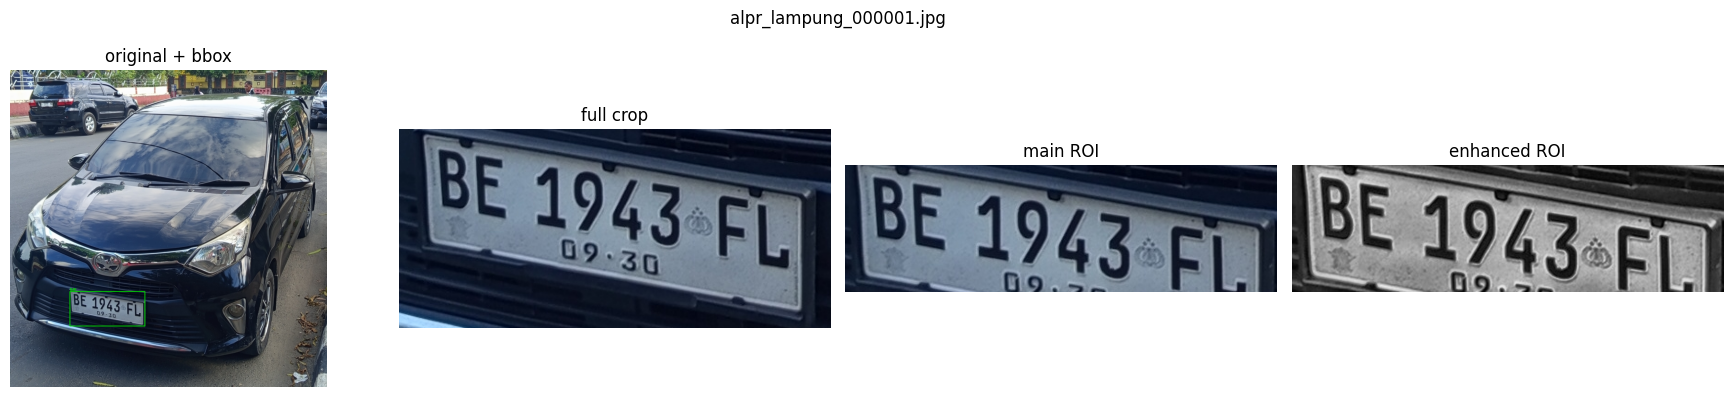

/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- full_crop --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE 1943FL 09·30,0.961842,"(217, 470, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE 1943FL 09·30,0.959333,"(217, 470, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE 1943FL 09·30,0.957013,"(217, 470, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE 1943FL 09·30,0.961842,"(217, 470, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE 1943FL 09·30,0.959333,"(217, 470, 3)",uint8


/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- main_roi --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE 1943 09,0.757959,"(130, 442, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE 1943 09,0.778447,"(130, 442, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE 1943F 09,0.732734,"(130, 442, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE 1943 09,0.757959,"(130, 442, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE 1943 09,0.778447,"(130, 442, 3)",uint8


/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- enhanced_main_roi --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE 1943,0.941915,"(260, 884, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE 1943,0.940128,"(260, 884, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE 1943,0.940128,"(260, 884, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE 1943,0.941915,"(260, 884, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE 1943,0.940128,"(260, 884, 3)",uint8



OCR smoke test: alpr_lampung_000015.jpg


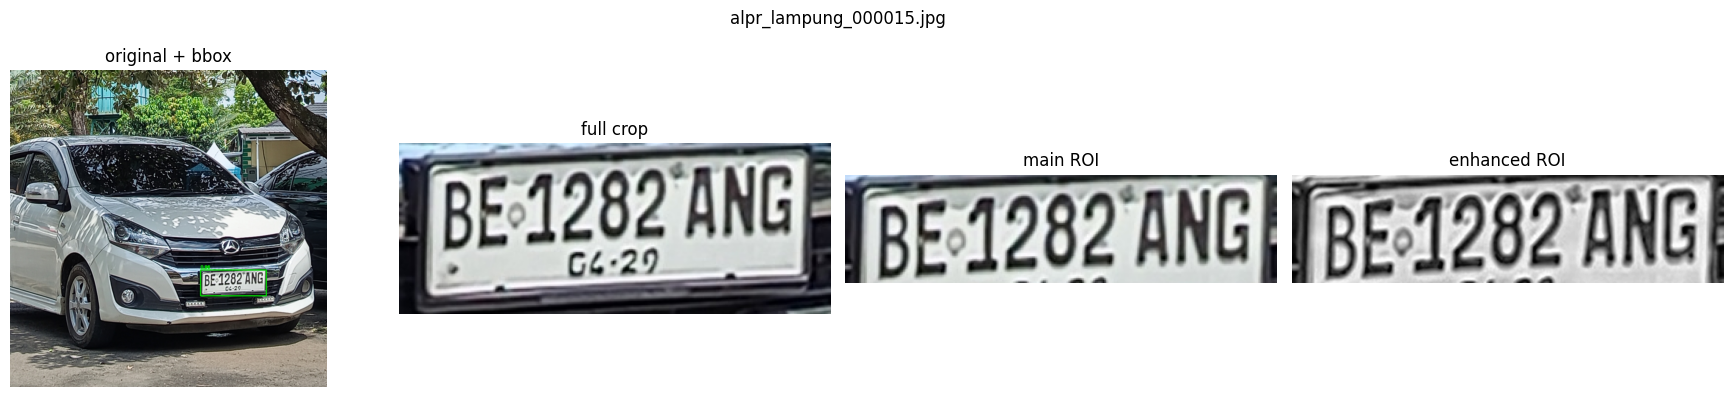

/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- full_crop --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE1282ANG C4·29,0.812865,"(116, 293, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE1282ANG C4.29,0.838994,"(116, 293, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE1282ANG C∠·29,0.817094,"(116, 293, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE1282ANG C4·29,0.812865,"(116, 293, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE1282ANG C4.29,0.838994,"(116, 293, 3)",uint8


/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- main_roi --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE1282ANG,0.993865,"(69, 275, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE1282ANG,0.995195,"(69, 275, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE1282ANG,0.994896,"(69, 275, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE1282ANG,0.993865,"(69, 275, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE1282ANG,0.995195,"(69, 275, 3)",uint8


/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- enhanced_main_roi --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,ANG BE1282,0.996583,"(138, 550, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,ANG BE1282,0.996649,"(138, 550, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,ANG BE1282,0.996649,"(138, 550, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,ANG BE1282,0.996583,"(138, 550, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,ANG BE1282,0.996649,"(138, 550, 3)",uint8



OCR smoke test: alpr_lampung_000026.jpg


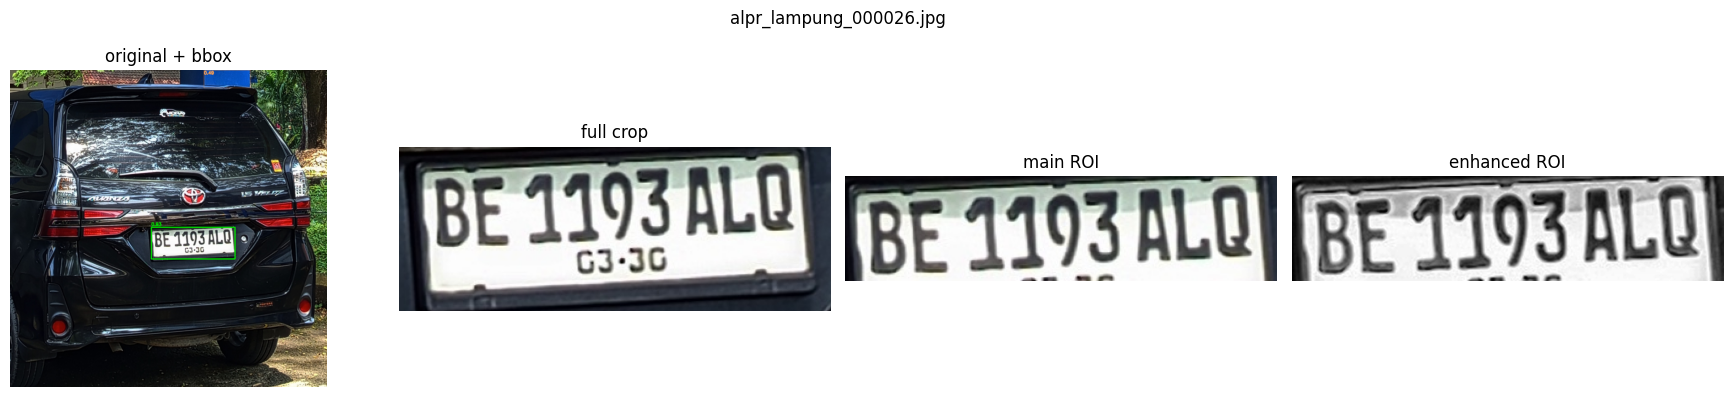

/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- full_crop --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE 1193ALQ C3·3C,0.868003,"(134, 352, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE 1193ALQ C3·3C,0.862110,"(134, 352, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE 1193ALQ C3·3C,0.884433,"(134, 352, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE 1193ALQ C3·3C,0.868003,"(134, 352, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE 1193ALQ C3·3C,0.862110,"(134, 352, 3)",uint8


/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- main_roi --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,BE1193ALQ,0.993032,"(80, 330, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE1193ALQ,0.994070,"(80, 330, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE1193ALQ,0.992550,"(80, 330, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,BE1193ALQ,0.993032,"(80, 330, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE1193ALQ,0.994070,"(80, 330, 3)",uint8


/tmp/ipykernel_1084/3064754247.py:51: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(str(temp_path))
/tmp/ipykernel_1084/3064754247.py:55: DeprecationWarning: Please use `predict` instead.
  output = ocr.ocr(image_bgr)


-- enhanced_main_roi --


,mode,status,ocr_execution_status,ocr_parse_status,error_message,parse_warning,raw_output_type,parsed_text,parsed_confidence,input_shape,input_dtype
0,predict_path,ok,ok,ok,,,builtins.list,1193ALQ BE,0.989521,"(160, 660, 3)",uint8
1,predict_bgr,ok,ok,ok,,,builtins.list,BE 1193ALQ,0.989649,"(160, 660, 3)",uint8
2,predict_rgb,ok,ok,ok,,,builtins.list,BE 1193ALQ,0.989649,"(160, 660, 3)",uint8
3,legacy_ocr_path,ok,ok,ok,,,builtins.list,1193ALQ BE,0.989521,"(160, 660, 3)",uint8
4,legacy_ocr_bgr,ok,ok,ok,,,builtins.list,BE 1193ALQ,0.989649,"(160, 660, 3)",uint8


OCR debug report sementara tersimpan: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs/ocr_debug_report_v2.csv
Smoke test berhasil menemukan raw OCR text pada 45 percobaan mode/source.


In [ ]:
def prepare_crops_for_debug(row: pd.Series) -> Dict[str, Any]:
    filename = row['filename']
    image_path = IMAGE_DIR / filename
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f'Gagal membaca image: {image_path}')
    yolo_result = model.predict(str(image_path), conf=CONF_THRES, iou=IOU_THRES, verbose=False)[0]
    selected = select_best_bbox_by_confidence(yolo_result)
    crop, crop_info = crop_with_padding(image_bgr, selected['bbox_xyxy'], CROP_PADDING_RATIO) if selected['bbox_xyxy'] is not None else (None, {'status': 'no_detection'})
    main_roi, roi_coords, roi_status = extract_main_plate_roi(crop)
    enhanced_roi = preprocess_for_ocr(main_roi)
    return {
        'filename': filename,
        'image_bgr': image_bgr,
        'yolo_result': yolo_result,
        'selected': selected,
        'crop': crop,
        'crop_info': crop_info,
        'main_roi': main_roi,
        'roi_coords': roi_coords,
        'roi_status': roi_status,
        'enhanced_roi': enhanced_roi,
    }


def show_debug_crops(debug_item: Dict[str, Any]) -> None:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    panels = [
        ('original + bbox', draw_detection_visualization(debug_item['image_bgr'], debug_item['yolo_result'], debug_item['selected'])),
        ('full crop', debug_item['crop']),
        ('main ROI', debug_item['main_roi']),
        ('enhanced ROI', debug_item['enhanced_roi']),
    ]
    for ax, (title, img) in zip(axes, panels):
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')
    fig.suptitle(debug_item['filename'])
    plt.tight_layout()
    plt.show()

smoke_debug_frames = []
if RUN_OCR_SMOKE_TEST:
    debug_count = min(DEBUG_NUM_IMAGES, len(eval_gt_df))
    for _, row in eval_gt_df.head(debug_count).iterrows():
        print('\n' + '=' * 80)
        print('OCR smoke test:', row['filename'])
        try:
            item = prepare_crops_for_debug(row)
            show_debug_crops(item)
            for source_name, img in [
                ('full_crop', item['crop']),
                ('main_roi', item['main_roi']),
                ('enhanced_main_roi', item['enhanced_roi']),
            ]:
                source_path = OCR_TEMP_DIR / f"{Path(row['filename']).stem}_{source_name}.jpg"
                if img is not None:
                    cv2.imwrite(str(source_path), _prepare_ocr_image(img))
                debug_df = debug_paddleocr_single_image(img, row['filename'], source_name=source_name, temp_dir=OCR_TEMP_DIR)
                smoke_debug_frames.append(debug_df)
                print(f'-- {source_name} --')
                display(debug_df[['mode','status','ocr_execution_status','ocr_parse_status','error_message','parse_warning','raw_output_type','parsed_text','parsed_confidence','input_shape','input_dtype']])
        except Exception as exc:
            print('Smoke test gagal:', exc)
            smoke_debug_frames.append(pd.DataFrame([{
                'image_name': row.get('filename', ''), 'source_name': 'smoke_test', 'mode': 'prepare_crop',
                'status': 'error', 'ocr_execution_status': 'not_run', 'ocr_parse_status': 'not_run',
                'error_message': str(exc), 'parse_warning': '', 'raw_output_type': '', 'raw_output_repr_sample': '',
                'parsed_text': '', 'parsed_confidence': None, 'input_shape': '', 'input_dtype': '', 'temp_path': '',
            }]))

    ocr_debug_smoke_df = pd.concat(smoke_debug_frames, ignore_index=True) if smoke_debug_frames else pd.DataFrame()
    if len(ocr_debug_smoke_df):
        ocr_debug_smoke_df.to_csv(OCR_DEBUG_REPORT_PATH, index=False)
        print('OCR debug report sementara tersimpan:', OCR_DEBUG_REPORT_PATH)
        ok_text_count = int(ocr_debug_smoke_df['parsed_text'].fillna('').str.strip().ne('').sum())
        if ok_text_count == 0:
            print('PERINGATAN: belum ada mode OCR yang menghasilkan teks. Lihat error_message dan raw_output_repr_sample di ocr_debug_report.csv sebelum evaluasi batch.')
        else:
            print('Smoke test berhasil menemukan raw OCR text pada', ok_text_count, 'percobaan mode/source.')
else:
    print('RUN_OCR_SMOKE_TEST=False, smoke test dilewati.')

if DEBUG_OCR_ONLY:
    print('DEBUG_OCR_ONLY=True: evaluasi batch penuh akan dilewati. Ubah menjadi False setelah smoke test OCR berhasil.')

## 16. Pipeline Improved per Gambar

Untuk setiap gambar, notebook menyimpan full crop, main ROI, enhanced ROI, raw OCR dari tiap source, kandidat terpilih, dan metrik evaluasi. Jika OCR masih salah, raw OCR dan notes tetap tersimpan untuk audit.

In [ ]:
candidate_debug_rows: List[Dict[str, Any]] = []


def _set_source_fields(result_row: Dict[str, Any], prefix: str, ocr_result: Dict[str, Any]) -> None:
    result_row[f'ocr_raw_text_{prefix}'] = ocr_result.get('raw_text', '')
    result_row[f'ocr_status_{prefix}'] = ocr_result.get('status', '')
    result_row[f'ocr_error_{prefix}'] = ocr_result.get('error', '')
    result_row[f'ocr_mode_{prefix}'] = ocr_result.get('mode_used', '')
    result_row[f'ocr_parse_status_{prefix}'] = ocr_result.get('ocr_parse_status', '')
    result_row[f'ocr_parse_warning_{prefix}'] = ocr_result.get('parse_warning', '')
    result_row[f'ocr_debug_input_shape_{prefix}'] = ocr_result.get('input_shape', '')
    result_row[f'ocr_debug_dtype_{prefix}'] = ocr_result.get('input_dtype', '')
    result_row[f'ocr_raw_output_type_{prefix}'] = ocr_result.get('raw_output_type', '')
    result_row[f'ocr_raw_output_repr_{prefix}'] = ocr_result.get('raw_output_repr_sample', '')


def serialize_ocr_lines(lines: List[Dict[str, Any]]) -> str:
    return serialize_lines(lines or [])


def infer_error_category(row: Dict[str, Any]) -> Tuple[str, str]:
    if row.get('detection_status') in ['no_detection', 'error']:
        return 'Deteksi gagal', 'YOLO tidak berhasil menemukan plat dengan benar.'
    if not row.get('crop_path'):
        return 'Crop gagal', 'Area plat tidak berhasil dipotong.'
    if row.get('ocr_status') == 'ocr_error':
        return 'OCR error', 'PaddleOCR mengalami error saat membaca crop.'
    if row.get('ocr_status') == 'ocr_empty':
        return 'OCR kosong', 'PaddleOCR berjalan tetapi tidak menghasilkan teks.'
    if row.get('candidate_status') != 'ok':
        return 'Kandidat plat tidak ditemukan', 'Teks OCR tidak dapat diparsing menjadi format plat BE.'
    if row.get('plate_exact_match'):
        return 'Benar', 'Plat dan wilayah terbaca benar.'
    gt = normalize_plate_text(row.get('plat_gt', ''))
    pred = normalize_plate_text(row.get('plat_pred_norm', ''))
    if gt and pred and len(gt) == len(pred) and Levenshtein.distance(gt, pred) == 1:
        return 'Huruf mirip terbaca salah', f'Satu karakter berbeda: ground truth {gt}, prediksi {pred}.'
    raw_text = ' '.join([str(row.get('ocr_raw_text_full_crop', '')), str(row.get('ocr_raw_text_main_roi', ''))])
    if re.search(r'\b\d{2}[\.\-·:]?\d{2}\b', raw_text):
        return 'Tanggal ikut terbaca', 'OCR membaca tanggal masa berlaku di bagian bawah plat.'
    return 'Kesalahan OCR lain', 'Hasil OCR berbeda dari ground truth dan perlu dicek visual.'


def evaluate_one_image_improved(row: pd.Series, image_dir: Optional[Path] = None, collect_candidate_debug: bool = True, run_label: str = 'final_test') -> Dict[str, Any]:
    start = time.perf_counter()
    filename = row['filename']
    active_image_dir = image_dir or IMAGE_DIR
    image_path = active_image_dir / filename
    notes = []

    result_row = {
        'filename': filename, 'split': row['split'], 'plat_gt': row['plat_gt'], 'plat_gt_norm': normalize_plate_text(row['plat_gt']),
        'kode_wilayah_gt': row['kode_wilayah_gt'], 'wilayah_gt': row['wilayah_gt'],
        'num_detections': 0, 'selected_confidence': None,
        'bbox_x1': None, 'bbox_y1': None, 'bbox_x2': None, 'bbox_y2': None,
        'detection_status': 'not_started', 'crop_path': '', 'main_roi_path': '', 'enhanced_roi_path': '',
        'ocr_lines_full_crop': '', 'ocr_lines_main_roi': '', 'ocr_lines_enhanced_main_roi': '',
        'ocr_raw_text_full_crop': '', 'ocr_raw_text_main_roi': '', 'ocr_raw_text_enhanced_main_roi': '',
        'ocr_status_full_crop': 'not_run', 'ocr_error_full_crop': '', 'ocr_mode_full_crop': '', 'ocr_parse_status_full_crop': 'not_run', 'ocr_parse_warning_full_crop': '',
        'ocr_status_main_roi': 'not_run', 'ocr_error_main_roi': '', 'ocr_mode_main_roi': '', 'ocr_parse_status_main_roi': 'not_run', 'ocr_parse_warning_main_roi': '',
        'ocr_status_enhanced_main_roi': 'not_run', 'ocr_error_enhanced_main_roi': '', 'ocr_mode_enhanced_main_roi': '', 'ocr_parse_status_enhanced_main_roi': 'not_run', 'ocr_parse_warning_enhanced_main_roi': '',
        'selected_ocr_source': '', 'selected_raw_line': '', 'selected_candidate_text': '', 'selected_candidate_score': 0.0,
        'candidate_rankings': '', 'removed_noise_suffix': '', 'candidate_filter_notes': '',
        'plat_pred': '', 'plat_pred_norm': '', 'kode_wilayah_pred': '', 'wilayah_pred': '',
        'cer': None, 'char_accuracy': None, 'plate_exact_match': False, 'region_correct': False,
        'ocr_status': 'not_started', 'ocr_execution_status': 'not_run', 'ocr_parse_status': 'not_run',
        'candidate_status': 'not_run', 'pipeline_status': 'not_started',
        'kategori_masalah': '', 'penjelasan_singkat': '',
        'inference_time_ms': None, 'notes': '',
        'baseline_full_crop_pred_norm': '', 'baseline_full_crop_cer': None,
        'baseline_full_crop_char_accuracy': None, 'baseline_full_crop_exact_match': False,
        'baseline_full_crop_region_correct': False,
    }

    image_bgr = None
    yolo_result = None
    selected = None
    crop = None
    main_roi = None
    enhanced_roi = None

    try:
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            raise ValueError(f'Gagal membaca image: {image_path}')
        yolo_result = model.predict(str(image_path), conf=CONF_THRES, iou=IOU_THRES, verbose=False)[0]
        selected = select_best_bbox_by_confidence(yolo_result)
        result_row['num_detections'] = selected['num_detections']
        result_row['selected_confidence'] = selected['confidence']
        result_row['detection_status'] = selected['status']
        if selected['bbox_xyxy'] is None:
            notes.append('YOLO tidak mendeteksi plat.')
            result_row['pipeline_status'] = 'no_detection'
            result_row['ocr_status'] = 'not_run'
            result_row['candidate_status'] = 'not_run_because_no_detection'
            return result_row

        bbox = selected['bbox_xyxy']
        result_row['bbox_x1'], result_row['bbox_y1'], result_row['bbox_x2'], result_row['bbox_y2'] = bbox
        crop, crop_info = crop_with_padding(image_bgr, bbox, CROP_PADDING_RATIO)
        if crop is None or crop_info.get('status') != 'ok':
            notes.append(f'Crop tidak valid: {crop_info}')
            result_row['pipeline_status'] = 'invalid_crop'
            result_row['ocr_status'] = 'not_run'
            result_row['candidate_status'] = 'not_run_because_invalid_crop'
            return result_row

        main_roi, roi_coords, roi_status = extract_main_plate_roi(crop)
        enhanced_roi = preprocess_for_ocr(main_roi)

        if SAVE_CROPS:
            crop_path = CROPS_DIR / f'{Path(filename).stem}_full_crop.jpg'
            main_roi_path = MAIN_ROI_DIR / f'{Path(filename).stem}_main_roi.jpg'
            enhanced_path = ENHANCED_ROI_DIR / f'{Path(filename).stem}_enhanced_main_roi.jpg'
            cv2.imwrite(str(crop_path), crop)
            if main_roi is not None:
                cv2.imwrite(str(main_roi_path), main_roi)
            if enhanced_roi is not None:
                cv2.imwrite(str(enhanced_path), enhanced_roi)
            result_row['crop_path'] = str(crop_path)
            result_row['main_roi_path'] = str(main_roi_path)
            result_row['enhanced_roi_path'] = str(enhanced_path)
    except Exception as exc:
        result_row['pipeline_status'] = 'detection_or_crop_error'
        result_row['detection_status'] = 'error'
        result_row['ocr_status'] = 'not_run'
        result_row['candidate_status'] = 'not_run_because_detection_or_crop_failed'
        notes.append(f'DETECTION/CROP ERROR: {exc}')
        return result_row

    try:
        full_ocr = run_paddleocr_robust(crop, 'full_crop', OCR_TEMP_DIR, image_name=filename, apply_line_filter=True)
        roi_ocr = run_paddleocr_robust(main_roi, 'main_roi', OCR_TEMP_DIR, image_name=filename, apply_line_filter=True)
        enh_ocr = run_paddleocr_robust(enhanced_roi, 'enhanced_main_roi', OCR_TEMP_DIR, image_name=filename, apply_line_filter=True)
        source_results = [full_ocr, roi_ocr, enh_ocr]

        _set_source_fields(result_row, 'full_crop', full_ocr)
        _set_source_fields(result_row, 'main_roi', roi_ocr)
        _set_source_fields(result_row, 'enhanced_main_roi', enh_ocr)
        result_row['ocr_lines_full_crop'] = serialize_ocr_lines(full_ocr.get('lines', []))
        result_row['ocr_lines_main_roi'] = serialize_ocr_lines(roi_ocr.get('lines', []))
        result_row['ocr_lines_enhanced_main_roi'] = serialize_ocr_lines(enh_ocr.get('lines', []))

        any_execution_ok = any(s.get('ocr_execution_status') == 'ok' for s in source_results)
        any_text = any(str(s.get('raw_text', '')).strip() for s in source_results)
        all_error = all(s.get('status') == 'ocr_error' for s in source_results)

        if any_text:
            result_row['ocr_status'] = 'ok'
            result_row['ocr_execution_status'] = 'ok'
            result_row['ocr_parse_status'] = 'ok'
        elif any_execution_ok:
            result_row['ocr_status'] = 'ocr_empty'
            result_row['ocr_execution_status'] = 'ok'
            result_row['ocr_parse_status'] = 'empty'
        elif all_error:
            result_row['ocr_status'] = 'ocr_error'
            result_row['ocr_execution_status'] = 'error'
            result_row['ocr_parse_status'] = 'not_run'
        else:
            result_row['ocr_status'] = 'ocr_error'
            result_row['ocr_execution_status'] = 'mixed_error'
            result_row['ocr_parse_status'] = 'not_run'

        baseline_norm = normalize_plate_text(full_ocr.get('raw_text', ''))
        result_row['baseline_full_crop_pred_norm'] = baseline_norm
        result_row['baseline_full_crop_cer'] = compute_cer(row['plat_gt'], baseline_norm) if baseline_norm else None
        result_row['baseline_full_crop_char_accuracy'] = compute_character_accuracy(row['plat_gt'], baseline_norm) if baseline_norm else None
        result_row['baseline_full_crop_exact_match'] = result_row['plat_gt_norm'] == baseline_norm
        baseline_code = extract_region_code(baseline_norm)
        baseline_region = identify_region_from_code(baseline_code)
        result_row['baseline_full_crop_region_correct'] = normalize_region_name(row['wilayah_gt']) == normalize_region_name(baseline_region)

        if result_row['ocr_execution_status'] == 'error':
            result_row['candidate_status'] = 'not_run_because_ocr_failed'
            result_row['candidate_filter_notes'] = 'not run because OCR execution failed'
        elif not any_text:
            result_row['candidate_status'] = 'not_run_because_ocr_empty'
            result_row['candidate_filter_notes'] = 'not run because OCR parser extracted no text'
        else:
            best = extract_best_plate_candidate_from_ocr_sources(source_results)
            result_row['selected_ocr_source'] = best['selected_source']
            result_row['selected_raw_line'] = best['selected_raw_line']
            result_row['selected_candidate_text'] = best['selected_candidate_text']
            result_row['selected_candidate_score'] = best['candidate_score']
            result_row['removed_noise_suffix'] = best['removed_noise_suffix']
            result_row['candidate_filter_notes'] = best['candidate_filter_notes']
            result_row['plat_pred_norm'] = best['plat_pred_norm']
            result_row['plat_pred'] = best['plat_pred_formatted']
            result_row['kode_wilayah_pred'] = extract_region_code(best['plat_pred_norm'])
            result_row['wilayah_pred'] = identify_region_from_code(result_row['kode_wilayah_pred'])
            result_row['candidate_status'] = 'ok' if best['plat_pred_norm'] else 'no_valid_candidate'

            candidates = sorted(best.get('all_candidates', []), key=lambda c: c.get('final_score', c.get('score', 0)), reverse=True)
            result_row['candidate_rankings'] = json.dumps(candidates, ensure_ascii=False, default=str)
            if collect_candidate_debug:
                for rank, cand in enumerate(candidates, start=1):
                    cand_row = dict(cand)
                    cand_row.update({
                        'run_label': run_label,
                        'filename': filename,
                        'plat_gt': row['plat_gt'],
                        'rank': rank,
                        'selected': cand.get('candidate_norm') == best.get('plat_pred_norm') and cand.get('source_kind') == best.get('selected_source') and cand.get('raw_line') == best.get('selected_raw_line'),
                    })
                    candidate_debug_rows.append(cand_row)

            if best['plat_pred_norm']:
                result_row['cer'] = compute_cer(row['plat_gt'], best['plat_pred_norm'])
                result_row['char_accuracy'] = compute_character_accuracy(row['plat_gt'], best['plat_pred_norm'])
                result_row['plate_exact_match'] = result_row['plat_gt_norm'] == best['plat_pred_norm']
                result_row['region_correct'] = normalize_region_name(row['wilayah_gt']) == normalize_region_name(result_row['wilayah_pred'])
            if result_row['removed_noise_suffix']:
                notes.append(result_row['candidate_filter_notes'])

        if result_row['num_detections'] > 1:
            notes.append('Multiple detections; bbox confidence tertinggi dipilih.')

    except Exception as exc:
        result_row['ocr_status'] = 'ocr_error'
        result_row['ocr_execution_status'] = 'error'
        result_row['ocr_parse_status'] = 'not_run'
        result_row['candidate_status'] = 'not_run_because_ocr_failed'
        notes.append(f'OCR/POSTPROCESS ERROR: {exc}')
    finally:
        result_row['pipeline_status'] = 'ok' if result_row['candidate_status'] == 'ok' else result_row.get('pipeline_status', 'completed_with_issue')
        result_row['inference_time_ms'] = (time.perf_counter() - start) * 1000
        category, explanation = infer_error_category(result_row)
        result_row['kategori_masalah'] = category
        result_row['penjelasan_singkat'] = explanation
        result_row['notes'] = ' | '.join(notes) if notes else 'OK'
        if SAVE_VISUALIZATIONS and image_bgr is not None and yolo_result is not None and selected is not None:
            try:
                save_improved_visualization(image_bgr, yolo_result, selected, crop, main_roi, enhanced_roi, result_row)
            except Exception as vis_exc:
                result_row['notes'] = (result_row['notes'] + f' | VISUALIZATION ERROR: {vis_exc}').strip(' |')

    return result_row

## 17. Visualisasi Full Crop vs Main ROI vs Enhanced ROI

Visualisasi menyimpan gambar asli dengan bbox, full crop, main ROI, enhanced ROI, raw OCR dari tiap source, kandidat akhir, dan perbandingan ground truth.

In [ ]:
def _rgb(image_bgr):
    if image_bgr is None:
        return None
    return cv2.cvtColor(_prepare_ocr_image(image_bgr), cv2.COLOR_BGR2RGB)


def _row_get(row: Dict[str, Any], key: str, default: str = '') -> str:
    value = row.get(key, default) if isinstance(row, dict) else row[key]
    if value is None:
        return default
    return str(value)


def status_label(row: Dict[str, Any]) -> str:
    if bool(row.get('plate_exact_match')) and bool(row.get('region_correct')):
        return 'Benar'
    return 'Salah'


def save_improved_visualization(image_bgr, yolo_result, selected, full_crop, main_roi, enhanced_roi, row):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.reshape(-1)

    det_bgr = draw_detection_visualization(image_bgr, yolo_result, selected)
    panels = [
        ('Gambar asli + bbox YOLO', det_bgr),
        ('Crop plat penuh', full_crop),
        ('ROI teks utama', main_roi),
        ('Enhanced ROI (fallback)', enhanced_roi),
    ]
    for ax, (title, image) in zip(axes, panels):
        if image is not None:
            ax.imshow(_rgb(image))
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    fig.suptitle(
        f"{_row_get(row, 'filename')}\n"
        f"GT: {_row_get(row, 'plat_gt')} -> {_row_get(row, 'wilayah_gt')}\n"
        f"Prediksi: {_row_get(row, 'plat_pred')} -> {_row_get(row, 'wilayah_pred')} | Status: {status_label(row)}\n"
        f"OCR full: {_row_get(row, 'ocr_raw_text_full_crop')} | OCR ROI: {_row_get(row, 'ocr_raw_text_main_roi')}\n"
        f"Dipilih: {_row_get(row, 'selected_raw_line')} dari {_row_get(row, 'selected_ocr_source')} | {_row_get(row, 'kategori_masalah')}: {_row_get(row, 'penjelasan_singkat')}",
        fontsize=9,
    )
    plt.tight_layout()
    vis_path = VIS_DIR / f"{Path(_row_get(row, 'filename')).stem}_pipeline_a_v2.jpg"
    fig.savefig(vis_path, dpi=130)
    plt.close(fig)
    shutil.copy2(vis_path, SAMPLE_DIR / vis_path.name)

## 18. Tuning ROI Valid dan Evaluasi Final Test v2

Jika `RUN_ROI_TUNING=True`, notebook mencoba beberapa nilai `MAIN_ROI_Y_MAX` pada split valid. Parameter terbaik dipilih dari akurasi wilayah tertinggi, lalu akurasi teks plat tertinggi, lalu CER terendah. Test set hanya digunakan untuk evaluasi final agar tidak overfit.

Jika runtime terbatas, `RUN_ROI_TUNING=False` memakai nilai default `MAIN_ROI_Y_MAX=0.65`.

In [ ]:
def run_pipeline_for_split(split_name: str, roi_y_max: float, save_outputs: bool, collect_debug: bool, run_label: str) -> pd.DataFrame:
    global MAIN_ROI_Y_MAX, IMAGE_DIR, SAVE_CROPS, SAVE_VISUALIZATIONS
    old_roi = MAIN_ROI_Y_MAX
    old_image_dir = IMAGE_DIR
    old_save_crops = SAVE_CROPS
    old_save_vis = SAVE_VISUALIZATIONS
    try:
        MAIN_ROI_Y_MAX = roi_y_max
        IMAGE_DIR = DATASET_ROOT_PATH / split_name / 'images'
        SAVE_CROPS = save_outputs
        SAVE_VISUALIZATIONS = save_outputs
        split_df = gt_df[gt_df['split'] == split_name].copy().reset_index(drop=True)
        if len(split_df) == 0:
            print(f'Split {split_name} kosong, dilewati.')
            return pd.DataFrame()
        rows = []
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f'{run_label} {split_name} roi={roi_y_max}'):
            rows.append(evaluate_one_image_improved(row, image_dir=IMAGE_DIR, collect_candidate_debug=collect_debug, run_label=run_label))
        return pd.DataFrame(rows)
    finally:
        MAIN_ROI_Y_MAX = old_roi
        IMAGE_DIR = old_image_dir
        SAVE_CROPS = old_save_crops
        SAVE_VISUALIZATIONS = old_save_vis


def summarize_for_tuning(df: pd.DataFrame, roi_y_max: float) -> Dict[str, Any]:
    if len(df) == 0:
        return {'main_roi_y_max': roi_y_max, 'num_images': 0, 'plate_exact_match_accuracy': 0.0, 'mean_CER': None, 'region_classification_accuracy': 0.0, 'no_valid_candidate_count': None, 'average_inference_time_ms': None}
    return {
        'main_roi_y_max': roi_y_max,
        'num_images': len(df),
        'plate_exact_match_accuracy': float(df['plate_exact_match'].fillna(False).mean()),
        'mean_CER': safe_mean(df['cer']) if 'safe_mean' in globals() else pd.to_numeric(df['cer'], errors='coerce').mean(),
        'region_classification_accuracy': float(df['region_correct'].fillna(False).mean()),
        'no_valid_candidate_count': int(df['candidate_status'].ne('ok').sum()),
        'average_inference_time_ms': float(pd.to_numeric(df['inference_time_ms'], errors='coerce').mean()),
    }

roi_tuning_results_path = OUTPUT_ROOT_PATH / 'hasil_tuning_roi.csv'
technical_roi_tuning_results_path = TECHNICAL_DIR / 'roi_tuning_results.csv'
if RUN_ROI_TUNING:
    tuning_rows = []
    for roi_y_max in MAIN_ROI_Y_MAX_CANDIDATES:
        tuning_df = run_pipeline_for_split(TUNING_SPLIT, roi_y_max, save_outputs=False, collect_debug=False, run_label=f'tuning_roi_{roi_y_max}')
        tuning_rows.append(summarize_for_tuning(tuning_df, roi_y_max))
    roi_tuning_df = pd.DataFrame(tuning_rows)
    roi_tuning_df = roi_tuning_df.sort_values(
        by=['region_classification_accuracy', 'plate_exact_match_accuracy', 'mean_CER'],
        ascending=[False, False, True],
        na_position='last'
    ).reset_index(drop=True)
    BEST_MAIN_ROI_Y_MAX = float(roi_tuning_df.iloc[0]['main_roi_y_max']) if len(roi_tuning_df) else MAIN_ROI_Y_MAX
    roi_tuning_df.to_csv(roi_tuning_results_path, index=False)
    roi_tuning_df.to_csv(technical_roi_tuning_results_path, index=False)
    print('Hasil tuning ROI disimpan:', roi_tuning_results_path)
    print('BEST_MAIN_ROI_Y_MAX:', BEST_MAIN_ROI_Y_MAX)
    display(roi_tuning_df)
else:
    BEST_MAIN_ROI_Y_MAX = MAIN_ROI_Y_MAX
    roi_tuning_df = pd.DataFrame([{
        'main_roi_y_max': MAIN_ROI_Y_MAX,
        'num_images': 0,
        'plate_exact_match_accuracy': None,
        'mean_CER': None,
        'region_classification_accuracy': None,
        'no_valid_candidate_count': None,
        'average_inference_time_ms': None,
        'notes': 'RUN_ROI_TUNING=False; default MAIN_ROI_Y_MAX digunakan.',
    }])
    roi_tuning_df.to_csv(roi_tuning_results_path, index=False)
    roi_tuning_df.to_csv(technical_roi_tuning_results_path, index=False)
    print('RUN_ROI_TUNING=False. Menggunakan MAIN_ROI_Y_MAX default:', BEST_MAIN_ROI_Y_MAX)

if DEBUG_OCR_ONLY:
    print('DEBUG_OCR_ONLY=True, evaluasi batch penuh dilewati.')
    improved_df = pd.DataFrame()
else:
    improved_df = run_pipeline_for_split(EVAL_SPLIT, BEST_MAIN_ROI_Y_MAX, save_outputs=True, collect_debug=True, run_label='improved_v2_test')

technical_ocr_results_v2_path = TECHNICAL_DIR / 'ocr_results_improved_v2.csv'
friendly_results_path = OUTPUT_ROOT_PATH / 'hasil_pipeline_a.csv'
improved_df.to_csv(technical_ocr_results_v2_path, index=False)
improved_df.to_csv(friendly_results_path, index=False)

candidate_debug_v2_path = TECHNICAL_DIR / 'candidate_debug_v2.csv'
friendly_candidate_debug_path = OUTPUT_ROOT_PATH / 'debug_kandidat_ocr.csv'
candidate_debug_df = pd.DataFrame(candidate_debug_rows)
candidate_debug_df.to_csv(candidate_debug_v2_path, index=False)
candidate_debug_df.to_csv(friendly_candidate_debug_path, index=False)

if ocr_debug_rows:
    pd.DataFrame(ocr_debug_rows).to_csv(OCR_DEBUG_REPORT_PATH, index=False)

print('hasil_pipeline_a.csv:', friendly_results_path)
print('ocr_results_improved_v2.csv:', technical_ocr_results_v2_path)
print('debug_kandidat_ocr.csv:', friendly_candidate_debug_path)
print('candidate_debug_v2.csv:', candidate_debug_v2_path)
display(improved_df.head())

RUN_ROI_TUNING=False. Menggunakan MAIN_ROI_Y_MAX default: 0.65


improved_v2_test test roi=0.65:   0%|          | 0/12 [00:00<?, ?it/s]

hasil_pipeline_a.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/hasil_pipeline_a.csv
ocr_results_improved_v2.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs/ocr_results_improved_v2.csv
debug_kandidat_ocr.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/debug_kandidat_ocr.csv
candidate_debug_v2.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs/candidate_debug_v2.csv


,filename,split,plat_gt,plat_gt_norm,kode_wilayah_gt,wilayah_gt,num_detections,selected_confidence,bbox_x1,bbox_y1,...,ocr_raw_output_type_full_crop,ocr_raw_output_repr_full_crop,ocr_debug_input_shape_main_roi,ocr_debug_dtype_main_roi,ocr_raw_output_type_main_roi,ocr_raw_output_repr_main_roi,ocr_debug_input_shape_enhanced_main_roi,ocr_debug_dtype_enhanced_main_roi,ocr_raw_output_type_enhanced_main_roi,ocr_raw_output_repr_enhanced_main_roi
0,alpr_lampung_000001.jpg,test,BE 1943 FL,BE1943FL,F,Kota Metro,1,0.913692,340.202728,1258.338013,...,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(130, 442, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(260, 884, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...
1,alpr_lampung_000015.jpg,test,BE 1282 ANG,BE1282ANG,A,Kota Bandar Lampung,1,0.957172,774.334473,811.994446,...,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(69, 275, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(138, 550, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...
2,alpr_lampung_000026.jpg,test,BE 1193 ALQ,BE1193ALQ,A,Kota Bandar Lampung,2,0.931537,540.492249,601.421509,...,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(80, 330, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(160, 660, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...
3,alpr_lampung_000036.jpg,test,BE 1498 GP,BE1498GP,G,Kabupaten Lampung Tengah,1,0.933424,342.314636,926.481567,...,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(90, 391, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(180, 782, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...
4,alpr_lampung_000044.jpg,test,BE 2581 GDC,BE2581GDC,G,Kabupaten Lampung Tengah,1,0.957411,767.014587,1121.075562,...,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(210, 685, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...,"(420, 1370, 3)",uint8,builtins.list,[{'input_path': '/content/drive/MyDrive/ALPR-L...


## 19. Evaluasi Improved dan Error Analysis

Metrik utama dihitung ulang setelah ROI, preprocessing, dan candidate scoring. Error analysis memisahkan error noise tanggal, kemungkinan mur/baut, kode wilayah, dan multiple detection.

In [ ]:
def safe_mean(series: pd.Series) -> Optional[float]:
    if series is None:
        return None
    numeric = pd.to_numeric(series, errors='coerce').dropna()
    return float(numeric.mean()) if len(numeric) else None


def safe_rate(mask: pd.Series, total: int) -> float:
    return float(mask.sum() / total) if total else 0.0


def count_extra_text_noise(df: pd.DataFrame) -> int:
    if len(df) == 0:
        return 0
    masks = []
    if 'removed_noise_suffix' in df:
        masks.append(df['removed_noise_suffix'].fillna('').astype(str).str.strip().ne(''))
    if 'candidate_filter_notes' in df:
        masks.append(df['candidate_filter_notes'].fillna('').str.contains('removed trailing|date-like', case=False, regex=True))
    if not masks:
        return 0
    combined = masks[0]
    for m in masks[1:]:
        combined = combined | m
    return int(combined.sum())

summary_improved_v2_path = TECHNICAL_DIR / 'evaluation_summary_improved_v2.json'
summary_improved_v2_csv_path = TECHNICAL_DIR / 'evaluation_summary_improved_v2.csv'
error_analysis_v2_path = TECHNICAL_DIR / 'error_analysis_improved_v2.csv'
friendly_summary_path = OUTPUT_ROOT_PATH / 'ringkasan_evaluasi_pipeline_a.csv'
friendly_error_path = OUTPUT_ROOT_PATH / 'analisis_kesalahan_pipeline_a.csv'
dashboard_path = OUTPUT_ROOT_PATH / 'dashboard_ringkas_pipeline_a.csv'

if len(improved_df) == 0:
    summary_improved = {'eval_split': EVAL_SPLIT, 'num_images': 0, 'message': 'Evaluasi belum dijalankan.'}
    error_analysis_improved = pd.DataFrame()
else:
    total = len(improved_df)
    detection_ok = improved_df['detection_status'].isin(['single_detection', 'multiple_detections_selected_highest_conf'])
    crop_ok = improved_df['crop_path'].fillna('').ne('')
    summary_improved = {
        'eval_split': EVAL_SPLIT,
        'main_roi_y_max_used': BEST_MAIN_ROI_Y_MAX,
        'num_images': total,
        'detection_success_rate': safe_rate(detection_ok, total),
        'crop_success_rate': safe_rate(crop_ok, total),
        'ocr_execution_success_rate': safe_rate(improved_df['ocr_execution_status'].eq('ok'), total),
        'ocr_success_rate': safe_rate(improved_df['ocr_status'].eq('ok'), total),
        'candidate_success_rate': safe_rate(improved_df['candidate_status'].eq('ok'), total),
        'no_valid_candidate_count': int(improved_df['candidate_status'].eq('no_valid_candidate').sum()),
        'plate_exact_match_accuracy': safe_rate(improved_df['plate_exact_match'].fillna(False).astype(bool), total),
        'mean_CER': safe_mean(improved_df['cer']),
        'mean_character_accuracy': safe_mean(improved_df['char_accuracy']),
        'region_classification_accuracy': safe_rate(improved_df['region_correct'].fillna(False).astype(bool), total),
        'average_inference_time_ms': safe_mean(improved_df['inference_time_ms']),
        'average_yolo_confidence': safe_mean(improved_df['selected_confidence']),
        'ocr_empty_count': int(improved_df['ocr_status'].eq('ocr_empty').sum()),
        'ocr_error_count': int(improved_df['ocr_status'].eq('ocr_error').sum()),
        'multiple_detection_count': int((improved_df['num_detections'] > 1).sum()),
        'trailing_noise_removed_count': count_extra_text_noise(improved_df),
        'date_line_rejected_count': int(improved_df.get('rejected_ocr_lines', pd.Series(dtype=str)).fillna('').str.contains('expiry|date', case=False, regex=True).sum()) if 'rejected_ocr_lines' in improved_df else 0,
        'suspected_extra_text_noise_count': count_extra_text_noise(improved_df),
        'region_error_count': int((improved_df['region_correct'] == False).sum()),
    }

    error_mask = (
        (improved_df['plate_exact_match'] == False) |
        (improved_df['region_correct'] == False) |
        improved_df['ocr_status'].ne('ok') |
        improved_df['candidate_status'].ne('ok') |
        improved_df['kode_wilayah_pred'].fillna('').eq('') |
        improved_df['wilayah_pred'].fillna('').eq('unknown')
    )
    error_analysis_improved = improved_df.loc[error_mask].copy()

with summary_improved_v2_path.open('w') as f:
    json.dump(summary_improved, f, indent=2)
pd.DataFrame([summary_improved]).to_csv(summary_improved_v2_csv_path, index=False)
pd.DataFrame([summary_improved]).to_csv(friendly_summary_path, index=False)
error_analysis_improved.to_csv(error_analysis_v2_path, index=False)
error_analysis_improved.to_csv(friendly_error_path, index=False)

if len(improved_df):
    dashboard_rows = [
        {'Aspek': 'Deteksi plat', 'Hasil': f"{int(detection_ok.sum())}/{len(improved_df)} berhasil", 'Arti Sederhana': 'Jumlah gambar yang platnya berhasil ditemukan oleh YOLO.'},
        {'Aspek': 'Crop plat', 'Hasil': f"{int(crop_ok.sum())}/{len(improved_df)} berhasil", 'Arti Sederhana': 'Jumlah plat yang berhasil dipotong untuk OCR.'},
        {'Aspek': 'Pembacaan OCR', 'Hasil': f"{int(improved_df['ocr_status'].eq('ok').sum())}/{len(improved_df)} berhasil", 'Arti Sederhana': 'OCR tidak error dan tidak kosong.'},
        {'Aspek': 'Teks plat benar persis', 'Hasil': f"{int(improved_df['plate_exact_match'].sum())}/{len(improved_df)} benar", 'Arti Sederhana': 'Hasil OCR sama persis dengan ground truth.'},
        {'Aspek': 'Wilayah benar', 'Hasil': f"{int(improved_df['region_correct'].sum())}/{len(improved_df)} benar", 'Arti Sederhana': 'Kabupaten/kota berhasil dipetakan dari kode huruf belakang plat.'},
        {'Aspek': 'Rata-rata waktu proses', 'Hasil': f"{summary_improved['average_inference_time_ms'] / 1000:.2f} detik/gambar", 'Arti Sederhana': 'Kecepatan masih belum real-time jika memakai konfigurasi Colab CPU untuk OCR.'},
        {'Aspek': 'Jumlah kesalahan', 'Hasil': f"{int((~improved_df['plate_exact_match'].fillna(False)).sum())} gambar", 'Arti Sederhana': 'Jumlah gambar yang teks platnya belum persis benar.'},
    ]
    dashboard_df = pd.DataFrame(dashboard_rows)
else:
    dashboard_df = pd.DataFrame()
dashboard_df.to_csv(dashboard_path, index=False)

print('ringkasan_evaluasi_pipeline_a.csv:', friendly_summary_path)
print('analisis_kesalahan_pipeline_a.csv:', friendly_error_path)
print('dashboard_ringkas_pipeline_a.csv:', dashboard_path)
print('evaluation_summary_improved_v2.json:', summary_improved_v2_path)
print('error_analysis_improved_v2.csv:', error_analysis_v2_path)
display(pd.DataFrame([summary_improved]))
display(dashboard_df)
if len(error_analysis_improved):
    display(error_analysis_improved[['filename','plat_gt','plat_pred','wilayah_gt','wilayah_pred','kategori_masalah','penjelasan_singkat','ocr_raw_text_full_crop','ocr_raw_text_main_roi','selected_ocr_source','selected_raw_line']])
else:
    print('Tidak ada error pada hasil final v2.')

ringkasan_evaluasi_pipeline_a.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/ringkasan_evaluasi_pipeline_a.csv
analisis_kesalahan_pipeline_a.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/analisis_kesalahan_pipeline_a.csv
dashboard_ringkas_pipeline_a.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/dashboard_ringkas_pipeline_a.csv
evaluation_summary_improved_v2.json: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs/evaluation_summary_improved_v2.json
error_analysis_improved_v2.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs/error_analysis_improved_v2.csv


,eval_split,main_roi_y_max_used,num_images,detection_success_rate,crop_success_rate,ocr_execution_success_rate,ocr_success_rate,candidate_success_rate,no_valid_candidate_count,plate_exact_match_accuracy,...,region_classification_accuracy,average_inference_time_ms,average_yolo_confidence,ocr_empty_count,ocr_error_count,multiple_detection_count,trailing_noise_removed_count,date_line_rejected_count,suspected_extra_text_noise_count,region_error_count
0,test,0.65,12,1.0,1.0,1.0,1.0,1.0,0,1.0,...,1.0,6973.666403,0.950784,0,0,1,2,0,2,0


,Aspek,Hasil,Arti Sederhana
0,Deteksi plat,12/12 berhasil,Jumlah gambar yang platnya berhasil ditemukan ...
1,Crop plat,12/12 berhasil,Jumlah plat yang berhasil dipotong untuk OCR.
2,Pembacaan OCR,12/12 berhasil,OCR tidak error dan tidak kosong.
3,Teks plat benar persis,12/12 benar,Hasil OCR sama persis dengan ground truth.
4,Wilayah benar,12/12 benar,Kabupaten/kota berhasil dipetakan dari kode hu...
5,Rata-rata waktu proses,6.97 detik/gambar,Kecepatan masih belum real-time jika memakai k...
6,Jumlah kesalahan,0 gambar,Jumlah gambar yang teks platnya belum persis b...


Tidak ada error pada hasil final v2.


## 19A. Analisis Khusus Kasus Perbaikan Utama

Cell ini menampilkan kandidat OCR untuk dua kasus yang sebelumnya bermasalah: `alpr_lampung_000044.jpg` dan `alpr_lampung_000168.jpg`. Tabel memperlihatkan semua kandidat, skor, source, raw line, dan kandidat terpilih. Tujuannya agar pembaca dapat melihat bahwa v2 memilih kandidat berdasarkan OCR line dan confidence, bukan berdasarkan ground truth.


,filename,rank,source,source_kind,raw_line,candidate_norm,ocr_confidence,source_bonus,pattern_score,confidence_bonus,line_quality_bonus,noise_penalty,agreement_bonus,conflict_adjustment,final_score,selected,notes
32,alpr_lampung_000044.jpg,1,full_crop,full_crop_joined,BE2581 GDC 09.30,BE2581GDC,0.907809,0.5,113.0,10.893710,0.0,-2.8,0.0,40.0,161.593710,True,removed trailing noisy suffix after valid 3-le...
33,alpr_lampung_000044.jpg,2,main_roi,main_roi_joined,BE2581 COC,BE2581COC,0.883874,0.8,118.0,10.606491,0.0,0.0,0.0,-10.0,119.406491,False,exact plate-like candidate without trailing no...
34,alpr_lampung_000044.jpg,3,full_crop,full_crop_joined,BE2581 GDC 09.30,BE2581GD,0.907809,0.5,107.0,10.893710,0.0,-6.5,0.0,0.0,111.893710,False,removed trailing noisy suffix after valid 2-le...
35,alpr_lampung_000044.jpg,4,main_roi,main_roi_joined,BE2581 COC,BE2581CO,0.883874,0.8,104.0,10.606491,0.0,-3.7,0.0,0.0,111.706491,False,removed trailing noisy suffix after valid 2-le...
36,alpr_lampung_000044.jpg,5,full_crop,full_crop_joined,BE2581 GDC 09.30,BE2581G,0.907809,0.5,105.0,10.893710,0.0,-7.2,0.0,0.0,109.193710,False,removed trailing noisy suffix after valid 1-le...
37,alpr_lampung_000044.jpg,6,main_roi,main_roi_joined,BE2581 COC,BE2581C,0.883874,0.8,102.0,10.606491,0.0,-4.4,0.0,0.0,109.006491,False,removed trailing noisy suffix after valid 1-le...
52,alpr_lampung_000168.jpg,1,main_roi,main_roi_joined,BE 2182.HX,BE2182HX,0.937366,0.8,112.0,11.248396,0.0,0.0,8.0,0.0,132.048396,True,exact plate-like candidate without trailing no...
53,alpr_lampung_000168.jpg,2,full_crop,full_crop_joined,BE 2182.HX 09.27,BE2182HX,0.938562,0.5,107.0,11.262743,0.0,-2.8,8.0,0.0,123.962743,False,removed trailing noisy suffix after valid 2-le...
54,alpr_lampung_000168.jpg,3,main_roi,main_roi_joined,BE 2182.HX,BE2182H,0.937366,0.8,102.0,11.248396,0.0,-0.7,8.0,0.0,121.348396,False,removed trailing noisy suffix after valid 1-le...
55,alpr_lampung_000168.jpg,4,full_crop,full_crop_joined,BE 2182.HX 09.27,BE2182H,0.938562,0.5,105.0,11.262743,0.0,-3.5,8.0,0.0,121.262743,False,removed trailing noisy suffix after valid 1-le...


,filename,plat_gt,plat_pred,wilayah_gt,wilayah_pred,selected_ocr_source,selected_raw_line,selected_candidate_score,plate_exact_match,region_correct,kategori_masalah,penjelasan_singkat
4,alpr_lampung_000044.jpg,BE 2581 GDC,BE 2581 GDC,Kabupaten Lampung Tengah,Kab. Lampung Tengah,full_crop_joined,BE2581 GDC 09.30,161.593710,True,True,Benar,Plat dan wilayah terbaca benar.
8,alpr_lampung_000168.jpg,BE 2182 HX,BE 2182 HX,Kabupaten Lampung Tengah,Kab. Lampung Tengah,main_roi_joined,BE 2182.HX,132.048396,True,True,Benar,Plat dan wilayah terbaca benar.


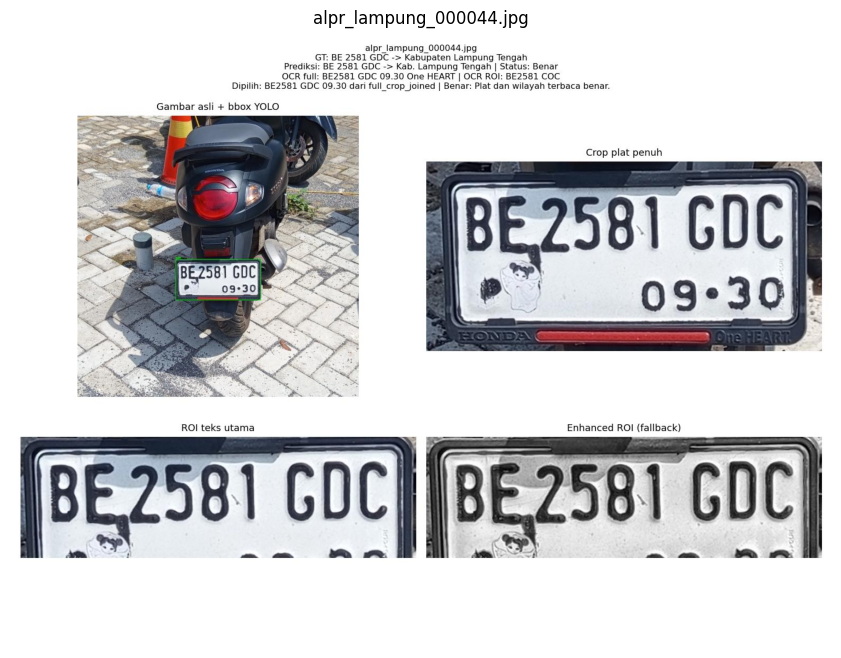

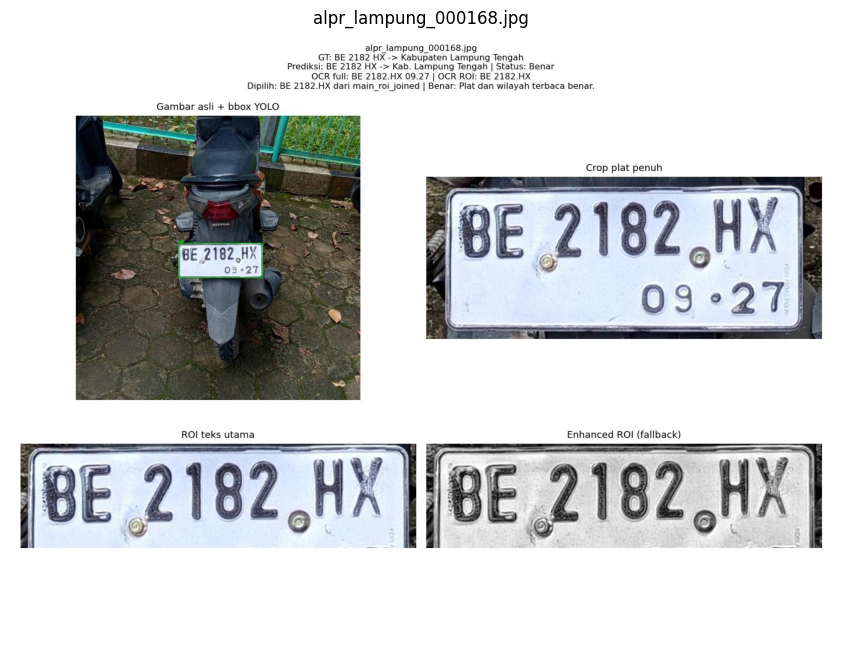

In [ ]:
SPECIAL_DEBUG_FILENAMES = ['alpr_lampung_000044.jpg', 'alpr_lampung_000168.jpg']

if 'candidate_debug_df' not in globals() or len(candidate_debug_df) == 0:
    print('candidate_debug_df belum tersedia. Jalankan evaluasi batch terlebih dahulu.')
else:
    special_candidates = candidate_debug_df[candidate_debug_df['filename'].isin(SPECIAL_DEBUG_FILENAMES)].copy()

    # PERBAIKAN 1: Menambahkan 'rank' ke dalam special_cols
    special_cols = [
        'filename', 'rank', 'source', 'source_kind', 'raw_line', 'candidate_norm', 'ocr_confidence',
        'source_bonus', 'pattern_score', 'confidence_bonus', 'line_quality_bonus', 'noise_penalty',
        'agreement_bonus', 'conflict_adjustment', 'final_score', 'selected', 'notes'
    ]

    display_cols = [c for c in special_cols if c in special_candidates.columns]

    if len(special_candidates) == 0:
        print('Tidak ada kandidat debug untuk file khusus. Pastikan evaluasi batch sudah dijalankan dari runtime bersih.')
    elif display_cols:
        table = special_candidates[display_cols].copy()

        # PERBAIKAN 2: Mengecek sort_cols berdasarkan table.columns agar terhindar dari KeyError
        sort_cols = [c for c in ['filename', 'rank', 'final_score'] if c in table.columns]

        if sort_cols:
            table = table.sort_values(sort_cols, ascending=[False if col == 'final_score' else True for col in sort_cols])
        display(table.head(80))
    else:
        display(special_candidates.head(80))

    # Blok untuk menampilkan hasil perbaikan (improved_df)
    if 'improved_df' in globals() and len(improved_df):
        special_results = improved_df[improved_df['filename'].isin(SPECIAL_DEBUG_FILENAMES)][[
            'filename','plat_gt','plat_pred','wilayah_gt','wilayah_pred','selected_ocr_source','selected_raw_line',
            'selected_candidate_score','plate_exact_match','region_correct','kategori_masalah','penjelasan_singkat'
        ]]
        display(special_results)

    # Blok untuk menampilkan visualisasi gambar
    for filename in SPECIAL_DEBUG_FILENAMES:
        vis_path = VIS_DIR / f"{Path(filename).stem}_pipeline_a_v2.jpg"
        if vis_path.exists():
            img = cv2.imread(str(vis_path))
            plt.figure(figsize=(12, 8))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(filename)
            plt.axis('off')
            plt.show()
        else:
            print('Visualisasi belum ditemukan:', vis_path)

## 20. Perbandingan Sebelum dan Sesudah Perbaikan

Tabel ini membandingkan hasil v1 dengan v2. V1 menggunakan candidate scoring yang masih cenderung memilih main ROI. V2 menggunakan OCR line-level scoring, agreement antar source, dan enhanced ROI sebagai fallback.

In [ ]:
comparison_path = OUTPUT_ROOT_PATH / 'perbandingan_sebelum_sesudah.csv'
technical_comparison_path = TECHNICAL_DIR / 'comparison_improved_v1_vs_v2.csv'
if len(improved_df) == 0:
    comparison_df = pd.DataFrame()
else:
    comparison_df = pd.DataFrame([
        {
            'method': 'improved_v1_roi_joined_candidate_scoring',
            'exact_match': 0.833333,
            'mean_CER': 0.019676,
            'char_accuracy': 0.980324,
            'region_accuracy': 0.916667,
            'ocr_error_count': 0,
            'no_valid_candidate_count': 0,
            'notes': 'Angka v1 dari hasil notebook sebelumnya. Candidate masih terlalu bias ke main_roi.',
        },
        {
            'method': 'improved_v2_line_source_candidate_scoring',
            'exact_match': summary_improved.get('plate_exact_match_accuracy'),
            'mean_CER': summary_improved.get('mean_CER'),
            'char_accuracy': summary_improved.get('mean_character_accuracy'),
            'region_accuracy': summary_improved.get('region_classification_accuracy'),
            'ocr_error_count': summary_improved.get('ocr_error_count'),
            'no_valid_candidate_count': summary_improved.get('no_valid_candidate_count'),
            'notes': 'V2 memakai candidate OCR per line, agreement antar source, dan enhanced ROI hanya fallback.',
        },
    ])
comparison_df.to_csv(comparison_path, index=False)
comparison_df.to_csv(technical_comparison_path, index=False)
print('perbandingan_sebelum_sesudah.csv:', comparison_path)
print('comparison_improved_v1_vs_v2.csv:', technical_comparison_path)
display(comparison_df)

before_after_rows = []
for _, row in improved_df.iterrows():
    before_after_rows.append({
        'Gambar': row['filename'],
        'OCR Mentah': row['ocr_raw_text_full_crop'],
        'Setelah Filter': row['plat_pred_norm'],
        'Ground Truth': row['plat_gt_norm'],
        'Status': 'Benar' if row['plate_exact_match'] else 'Salah',
    })
before_after_df = pd.DataFrame(before_after_rows)
before_after_path = OUTPUT_ROOT_PATH / 'perbandingan_ocr_mentah_dan_filter.csv'
before_after_df.to_csv(before_after_path, index=False)
print('perbandingan_ocr_mentah_dan_filter.csv:', before_after_path)
display(before_after_df.head(20))

perbandingan_sebelum_sesudah.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/perbandingan_sebelum_sesudah.csv
comparison_improved_v1_vs_v2.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/technical_outputs/comparison_improved_v1_vs_v2.csv


,method,exact_match,mean_CER,char_accuracy,region_accuracy,ocr_error_count,no_valid_candidate_count,notes
0,improved_v1_roi_joined_candidate_scoring,0.833333,0.019676,0.980324,0.916667,0,0,Angka v1 dari hasil notebook sebelumnya. Candi...
1,improved_v2_line_source_candidate_scoring,1.000000,0.000000,1.000000,1.000000,0,0,"V2 memakai candidate OCR per line, agreement a..."


perbandingan_ocr_mentah_dan_filter.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/perbandingan_ocr_mentah_dan_filter.csv


,Gambar,OCR Mentah,Setelah Filter,Ground Truth,Status
0,alpr_lampung_000001.jpg,BE 1943FL 09·30,BE1943FL,BE1943FL,Benar
1,alpr_lampung_000015.jpg,BE1282ANG C4·29,BE1282ANG,BE1282ANG,Benar
2,alpr_lampung_000026.jpg,BE 1193ALQ C3·3C,BE1193ALQ,BE1193ALQ,Benar
3,alpr_lampung_000036.jpg,BE 1498 GP 11·29,BE1498GP,BE1498GP,Benar
4,alpr_lampung_000044.jpg,BE2581 GDC 09.30 One HEART,BE2581GDC,BE2581GDC,Benar
5,alpr_lampung_000117.jpg,BE 1482 BW 11.28,BE1482BW,BE1482BW,Benar
6,alpr_lampung_000127.jpg,BE 2919 RG 1d0 R 07.29,BE2919RG,BE2919RG,Benar
7,alpr_lampung_000133.jpg,1707 CF BE 02.28,BE1707CF,BE1707CF,Benar
8,alpr_lampung_000168.jpg,BE 2182.HX 09.27,BE2182HX,BE2182HX,Benar
9,alpr_lampung_000174.jpg,BE2476NCZ 05.29,BE2476NCZ,BE2476NCZ,Benar


## 21. Visualisasi Sampel Improved

Visualisasi disimpan ke `visualizations_improved/` dan beberapa sampel disalin ke `sample_predictions_improved/`. Gambar menampilkan original+bbox, full crop, main ROI, enhanced ROI, raw OCR dari tiap source, kandidat final, dan status benar/salah.

In [ ]:
if DEBUG_OCR_ONLY or len(improved_df) == 0:
    print('Visualisasi sampel full pipeline dilewati karena DEBUG_OCR_ONLY=True atau evaluasi batch belum dijalankan.')
    print('Untuk diagnosis OCR, lihat gambar crop dan tabel smoke test pada section Smoke Test OCR Multi-Mode.')
else:
    vis_files = sorted(VIS_DIR.glob('*_improved.jpg'))
    if not vis_files:
        print('Belum ada visualisasi improved.')
    else:
        sample_count = min(20, max(12, min(len(vis_files), 16)))
        sample_files = random.sample(vis_files, sample_count) if len(vis_files) > sample_count else vis_files
        cols = 3
        rows = math.ceil(len(sample_files) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
        axes = np.array(axes).reshape(-1)
        for ax, path in zip(axes, sample_files):
            img = cv2.imread(str(path))
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(path.name, fontsize=8)
            ax.axis('off')
        for ax in axes[len(sample_files):]:
            ax.axis('off')
        plt.tight_layout()
        plt.show()
        print('Visualizations dir:', VIS_DIR)
        print('Sample predictions dir:', SAMPLE_DIR)

Belum ada visualisasi improved.


## 22. Dashboard Ringkas Pipeline A dan Rekomendasi

Bagian akhir menampilkan file output, dashboard ringkas, dan ringkasan bahasa sederhana agar hasil notebook mudah dipahami oleh pembaca non-teknis.

In [ ]:
print('Output ramah pembaca:')
print('hasil_pipeline_a.csv                 :', friendly_results_path)
print('ringkasan_evaluasi_pipeline_a.csv    :', friendly_summary_path)
print('analisis_kesalahan_pipeline_a.csv    :', friendly_error_path)
print('perbandingan_sebelum_sesudah.csv     :', comparison_path)
print('dashboard_ringkas_pipeline_a.csv     :', dashboard_path)
print('debug_kandidat_ocr.csv               :', friendly_candidate_debug_path)
print('hasil_tuning_roi.csv                 :', roi_tuning_results_path)
print('visualisasi_hasil                    :', VIS_DIR)
print('crop_plat                            :', CROPS_DIR)
print('roi_teks_utama                       :', MAIN_ROI_DIR)
print()
print('Output teknis:')
print('technical_outputs                    :', TECHNICAL_DIR)
print('ocr_results_improved_v2.csv          :', technical_ocr_results_v2_path)
print('evaluation_summary_improved_v2.json  :', summary_improved_v2_path)
print('evaluation_summary_improved_v2.csv   :', summary_improved_v2_csv_path)
print('candidate_debug_v2.csv               :', candidate_debug_v2_path)
print('error_analysis_improved_v2.csv       :', error_analysis_v2_path)
print('comparison_improved_v1_vs_v2.csv     :', technical_comparison_path)

print('\nDashboard Ringkas Pipeline A')
display(dashboard_df)

if len(improved_df):
    total = len(improved_df)
    exact = int(improved_df['plate_exact_match'].sum())
    region = int(improved_df['region_correct'].sum())
    det = int(improved_df['detection_status'].isin(['single_detection', 'multiple_detections_selected_highest_conf']).sum())
    ocr_ok = int(improved_df['ocr_status'].eq('ok').sum())
    print('\nRingkasan Hasil untuk Pembaca Umum')
    print(f'- Dari {total} gambar uji, YOLO berhasil menemukan plat pada {det} gambar.')
    print(f'- OCR berhasil membaca teks pada {ocr_ok} gambar.')
    print(f'- Sebanyak {exact} dari {total} plat terbaca persis sama dengan ground truth.')
    print(f'- Sebanyak {region} dari {total} wilayah berhasil dikenali dengan benar.')
    print('- Kesalahan yang tersisa umumnya terjadi karena huruf yang mirip atau kualitas crop/OCR pada karakter tertentu.')
    print('- Sistem sudah layak sebagai baseline Pipeline A, tetapi tetap perlu diuji pada data yang lebih banyak sebelum klaim final yang kuat.')

    if summary_improved.get('region_classification_accuracy', 0) >= 0.90 and summary_improved.get('mean_character_accuracy', 0) >= 0.95:
        print('\nKesimpulan: Pipeline A v2 layak dijadikan hasil baseline dan dapat dilanjutkan ke Pipeline B sebagai pembanding.')
    else:
        print('\nKesimpulan: Pipeline A v2 sudah berjalan, tetapi sebaiknya perbaiki error OCR yang tersisa sebelum perbandingan final dengan Pipeline B.')
else:
    print('Evaluasi belum menghasilkan data.')

Output ramah pembaca:
hasil_pipeline_a.csv                 : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/hasil_pipeline_a.csv
ringkasan_evaluasi_pipeline_a.csv    : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/ringkasan_evaluasi_pipeline_a.csv
analisis_kesalahan_pipeline_a.csv    : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/analisis_kesalahan_pipeline_a.csv
perbandingan_sebelum_sesudah.csv     : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/perbandingan_sebelum_sesudah.csv
dashboard_ringkas_pipeline_a.csv     : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/dashboard_ringkas_pipeline_a.csv
debug_kandidat_ocr.csv               : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/debug_kandidat_ocr.csv
hasil_tuning_roi.csv                 : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/hasil_tuning_roi.csv
visualisasi_hasil                    : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_a/visualisasi_hasil
crop_plat

,Aspek,Hasil,Arti Sederhana
0,Deteksi plat,12/12 berhasil,Jumlah gambar yang platnya berhasil ditemukan ...
1,Crop plat,12/12 berhasil,Jumlah plat yang berhasil dipotong untuk OCR.
2,Pembacaan OCR,12/12 berhasil,OCR tidak error dan tidak kosong.
3,Teks plat benar persis,12/12 benar,Hasil OCR sama persis dengan ground truth.
4,Wilayah benar,12/12 benar,Kabupaten/kota berhasil dipetakan dari kode hu...
5,Rata-rata waktu proses,6.97 detik/gambar,Kecepatan masih belum real-time jika memakai k...
6,Jumlah kesalahan,0 gambar,Jumlah gambar yang teks platnya belum persis b...



Ringkasan Hasil untuk Pembaca Umum
- Dari 12 gambar uji, YOLO berhasil menemukan plat pada 12 gambar.
- OCR berhasil membaca teks pada 12 gambar.
- Sebanyak 12 dari 12 plat terbaca persis sama dengan ground truth.
- Sebanyak 12 dari 12 wilayah berhasil dikenali dengan benar.
- Kesalahan yang tersisa umumnya terjadi karena huruf yang mirip atau kualitas crop/OCR pada karakter tertentu.
- Sistem sudah layak sebagai baseline Pipeline A, tetapi tetap perlu diuji pada data yang lebih banyak sebelum klaim final yang kuat.

Kesimpulan: Pipeline A v2 layak dijadikan hasil baseline dan dapat dilanjutkan ke Pipeline B sebagai pembanding.
